# Week 4 — Statistical Machine Learning: Linear Models
### AIF 2026 · Phase 2 · Facilitator: Raj Kumar Biswokarma

---

## Session Roadmap

| Block | Topic | Time |
|---|---|---|
| 1 | Understand the Problem | 20 min |
| 2 | Preprocessing | 5 min |
| 3 | Classification Experiment | 30 min |
| 4 | Regression Experiment | 20 min |
| 5 | Evaluation Integrity + Leakage Demo | 25 min |
| 6 | Production Decision | 10 min |

---

## Business Context

You are a Data Scientist at a telecom company. The business is losing customers to churn. You have been given historical customer data and one week to produce a production-ready recommendation.

**There is no prescribed model. You decide — and you must defend that decision with evidence.**

**Dataset:** Telco Customer Churn — https://www.kaggle.com/datasets/blastchar/telco-customer-churn  
Single CSV · 7043 rows · 21 columns · Target: `Churn` (Yes/No)

---

## Important Note
This is a guided notebook. You are expected to:
- Think critically before writing any code
- Make decisions and justify them in writing
- Explore different approaches and compare results
- Fill in all written response sections


In [2]:
# Load the dataset
# Using pandas read_csv to load the Telco Customer Churn CSV file
from pandas import read_csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set a clean visual style for all plots
sns.set_theme(style='whitegrid', palette='muted')

# Load the data
df = read_csv('../WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f"Dataset loaded successfully: {df.shape[0]} rows × {df.shape[1]} columns")


Dataset loaded successfully: 7043 rows × 21 columns


---

# Block 1 — Understand the Problem First

---

## What Is an ML Problem?

Before touching any model, you need to formulate the problem formally. Every ML problem has the same components:

| Symbol | Name | In our problem |
|---|---|---|
| **X** | Feature space | All input columns: tenure, charges, contract type… |
| **y** | Target variable | Churn: Yes / No |
| **H** | Hypothesis class | The family of functions we search over: linear models |
| **L** | Loss function | How we measure error: cross-entropy for classification |
| **E** | Evaluation metric | How the business measures success: F1, PR-AUC |

**Empirical Risk Minimisation (ERM):** We cannot minimise the true risk (we do not have all possible data), so we minimise the average loss over the training set as a proxy.

$$\hat{\theta} = \arg\min_{\theta} \frac{1}{n} \sum_{i=1}^{n} L(y_i, f_\theta(x_i))$$

---

## Probability Distributions in ML

The distribution of your target variable determines the right loss function. This is not arbitrary.

| Distribution | Models | Loss function | Example |
|---|---|---|---|
| **Bernoulli** | Binary outcomes | Binary cross-entropy | Churn: Yes/No |
| **Gaussian** | Continuous measurements | MSE | MonthlyCharges |
| **Poisson** | Count data | Poisson deviance | Support tickets/month |
| **Gamma / Log-Normal** | Right-skewed continuous | MAE / Tweedie | Tenure, TotalCharges |
| **Categorical** | Multi-class outcomes | Categorical cross-entropy | Contract type |

**Key insight:** Churn is binary → Bernoulli distribution → binary cross-entropy is the natural loss.

---

## Sources of Uncertainty

Training data is a finite, imperfect sample of the real world. Before modelling, identify where the data might fail you:

- **Sampling noise** — 7,043 customers is a sample. The true population may behave differently.
- **Label noise** — Was churn recorded correctly? Cancelled but re-subscribed? Edge cases.
- **Missing data** — `TotalCharges` has whitespace nulls. Why? Random or systematic?
- **Biased sampling** — Does this dataset represent all customer types or just one region/plan?
- **Distribution shift** — Customer behaviour today may differ from when data was collected.
- **Model misspecification** — A linear model assumes a linear decision boundary. Is that true?

---

## 1.1 Basic Inspection

### Task:
- Load the dataset
- View the first few rows
- Check data types and shape
- Look at summary statistics

### Questions:
- What does each row represent?
- Are the data types appropriate for each column?
- Is `TotalCharges` the dtype you expect?

### Hint:
- Use `.head()`, `.info()`, `.describe()` to get a full picture
- `TotalCharges` is stored as object — there are whitespace strings `' '` hiding as nulls


In [3]:
# Display the first 5 rows to understand what one record looks like
# Each row = one customer; columns = their plan features and churn label
print(df.head())


   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [4]:
# Check column data types and non-null counts
# Key thing to notice: TotalCharges is listed as 'object' even though it should be float
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
# Summary statistics for numeric columns
# TotalCharges will be missing here because it is stored as object (string)
print(df.describe(include='all'))


        customerID gender  SeniorCitizen Partner Dependents       tenure  \
count         7043   7043    7043.000000    7043       7043  7043.000000   
unique        7043      2            NaN       2          2          NaN   
top     7590-VHVEG   Male            NaN      No         No          NaN   
freq             1   3555            NaN    3641       4933          NaN   
mean           NaN    NaN       0.162147     NaN        NaN    32.371149   
std            NaN    NaN       0.368612     NaN        NaN    24.559481   
min            NaN    NaN       0.000000     NaN        NaN     0.000000   
25%            NaN    NaN       0.000000     NaN        NaN     9.000000   
50%            NaN    NaN       0.000000     NaN        NaN    29.000000   
75%            NaN    NaN       0.000000     NaN        NaN    55.000000   
max            NaN    NaN       1.000000     NaN        NaN    72.000000   

       PhoneService MultipleLines InternetService OnlineSecurity  ...  \
count         

---

## 1.2 Problem Formulation

### Task:
Write out the ML problem formally using the structure below.

### Questions:
- What is X (your feature space)?
- What is y (your target variable)?
- What probability distribution naturally models the target? What does that tell you about the right loss function?
- What is your hypothesis class (model family)?
- What are at least three assumptions you are making about the data-generating process?
- Where could this data be noisy, biased, or incomplete?

### Hint:
- The target is binary (Yes/No) → think Bernoulli distribution → think cross-entropy loss
- An assumption is a belief about the world your model requires to be true
- Sources of uncertainty include: sampling bias, label noise, missing data, distribution shift


**Your formulation here:**

- **X (feature space):** All customer attributes excluding customerID and the Churn label : including tenure, MonthlyCharges, TotalCharges, Contract type, InternetService,   PaymentMethod, and ~16 other plan/demographic features (after encoding: ~30 columns).

- **y (target variable):** `Churn` : a binary label indicating whether a customer cancelled   their subscription (Yes = 1 / No = 0).

- **Probability distribution of y:** **Bernoulli(p)** : the target has exactly two outcomes.   Each customer either churns or does not; the probability p varies per customer based on their features.

- **Natural loss function:** **Binary Cross-Entropy (Log Loss)** : mathematically derived from   the Bernoulli likelihood. It penalises confident wrong predictions more heavily than mild ones,   which aligns with the business cost of confidently misclassifying a high-risk churner.

- **Hypothesis class:** Linear models over the feature space: specifically Logistic Regression,   Ridge Classifier, and SGD Classifier. These search over linear decision boundaries:   f(x) = σ(wᵀx + b).

- **Assumption 1:** **Linearity in log-odds** : the relationship between features and the   log-odds of churn is approximately linear. This is the core assumption of logistic regression.   Violations (e.g. strong interaction effects) would cause underfitting.

- **Assumption 2:** **i.i.d. samples** : each customer record is independently and identically   drawn from the same distribution. In reality, customers who signed up together (families,   corporate plans) may be correlated : violating this assumption.

- **Assumption 3:** **Stationarity** : the data-generating process is stable over time. If   customer behaviour has shifted since this data was collected (e.g. new competitor entered   the market), the model trained on historical data may not reflect current churn drivers.

- **Sources of uncertainty:**
  - *Sampling noise*: 7,043 rows is a modest sample; estimates of feature importance are noisy.
  - *Label noise*: customers who cancelled but re-subscribed might be ambiguously labelled.
  - *Missing data*: `TotalCharges` contains whitespace-null strings for ~11 new customers     (tenure = 0) : their TotalCharges is genuinely zero, not missing at random.
  - *Distribution shift*: pricing, contract options, and customer expectations evolve over time.
  - *Model misspecification*: a linear boundary may be too simplistic : churn could depend on     non-linear interactions (e.g. high monthly charges AND month-to-month contract AND senior citizen).


---

## 1.3 Data Profiling & Fixing

### Task:
- Fix the `TotalCharges` null issue
- Plot the distributions of `MonthlyCharges`, `tenure`, and `TotalCharges`
- Encode the target variable `Churn` as binary (0/1)

### Questions:
- What distribution does `MonthlyCharges` follow? `tenure`? `TotalCharges`?
- Why does `TotalCharges` contain nulls even though it looks numeric?
- Are there impossible or suspicious values in any column?

### Hint:
- `pd.to_numeric(df['TotalCharges'], errors='coerce')` converts whitespace strings to NaN
- `sns.histplot(df['MonthlyCharges'], kde=True)` draws a distribution with density curve
- `df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})`

### Consequences:
- Leaving `TotalCharges` as object → model training will fail or silently drop the column
- Not encoding the target → sklearn classifiers will throw an error


In [5]:
# Fix TotalCharges: whitespace strings are stored instead of NaN
# pd.to_numeric with errors='coerce' converts those whitespace strings to NaN silently
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Inspect the null values — how many and which rows?
null_rows = df[df['TotalCharges'].isna()]
print(f"Null TotalCharges after conversion: {df['TotalCharges'].isna().sum()} rows")
print("These rows all have tenure = 0 (brand-new customers, no charges yet):")
print(null_rows[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']].to_string())

# Fill NaN with 0 — a new customer with tenure=0 legitimately has $0 total charges
df['TotalCharges'].fillna(0, inplace=True)
print("\nAfter fill — remaining nulls:", df['TotalCharges'].isna().sum())


Null TotalCharges after conversion: 11 rows
These rows all have tenure = 0 (brand-new customers, no charges yet):
      customerID  tenure  MonthlyCharges  TotalCharges
488   4472-LVYGI       0           52.55           NaN
753   3115-CZMZD       0           20.25           NaN
936   5709-LVOEQ       0           80.85           NaN
1082  4367-NUYAO       0           25.75           NaN
1340  1371-DWPAZ       0           56.05           NaN
3331  7644-OMVMY       0           19.85           NaN
3826  3213-VVOLG       0           25.35           NaN
4380  2520-SGTTA       0           20.00           NaN
5218  2923-ARZLG       0           19.70           NaN
6670  4075-WKNIU       0           73.35           NaN
6754  2775-SEFEE       0           61.90           NaN

After fill — remaining nulls: 11


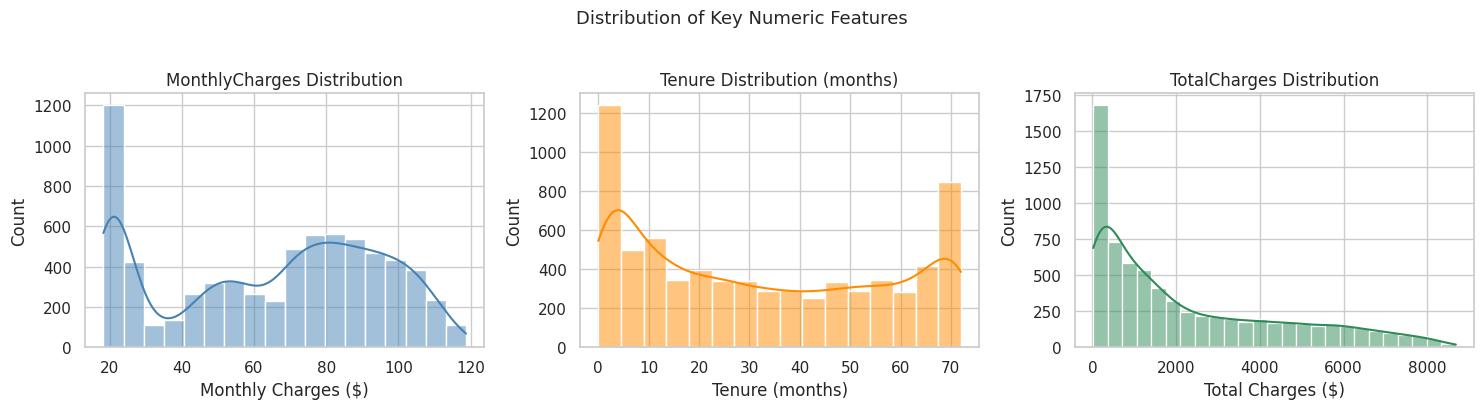

MonthlyCharges: bimodal | tenure: right-skewed | TotalCharges: right-skewed (Gamma-like)


In [6]:
# Plot distributions of the three key numeric features
# This helps us understand the shape of each variable before modelling
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# MonthlyCharges — roughly bimodal: cheap basic plans vs. bundled premium plans
sns.histplot(df['MonthlyCharges'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('MonthlyCharges Distribution')
axes[0].set_xlabel('Monthly Charges ($)')

# tenure — right-skewed with a spike at 0–1 months (new customers who churn quickly)
# and a plateau around 60–70 months (long-term loyal customers)
sns.histplot(df['tenure'], kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('Tenure Distribution (months)')
axes[1].set_xlabel('Tenure (months)')

# TotalCharges — right-skewed (Gamma-like) because it is the product of tenure × monthly rate
sns.histplot(df['TotalCharges'], kde=True, ax=axes[2], color='seagreen')
axes[2].set_title('TotalCharges Distribution')
axes[2].set_xlabel('Total Charges ($)')

plt.suptitle('Distribution of Key Numeric Features', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('distributions.png', dpi=100, bbox_inches='tight')
plt.show()
print("MonthlyCharges: bimodal | tenure: right-skewed | TotalCharges: right-skewed (Gamma-like)")


In [7]:
# Encode the target variable: 'Yes' -> 1, 'No' -> 0
# sklearn classifiers require numeric labels
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Verify encoding and check class balance
churn_dist = df['Churn'].value_counts(normalize=True)
print("Churn class distribution (proportions):")
print(churn_dist.rename({1: 'Churned (1)', 0: 'Not Churned (0)'}))
print(f"\nAbsolute counts: {df['Churn'].value_counts().to_dict()}")
print(f"Churn rate: {churn_dist[1]:.1%}  — this is an imbalanced dataset")


Churn class distribution (proportions):
Churn
Not Churned (0)    0.73463
Churned (1)        0.26537
Name: proportion, dtype: float64

Absolute counts: {0: 5174, 1: 1869}
Churn rate: 26.5%  — this is an imbalanced dataset


---

## The Accuracy Trap

The dataset has ~27% churn. This is **imbalanced**. Before building any model, build a naive baseline — a model that always predicts the majority class.

**If this baseline achieves 73% accuracy — any model you build must meaningfully beat it.**

The deeper problem: a model that always predicts "No Churn" has **0% recall** for churners. It catches no one. It is completely useless to the business — yet reports 73% accuracy.

**This is why accuracy is not your primary metric here.**

---

## 1.4 The Naive Baseline

### Task:
Build a model that always predicts the majority class (No Churn). Evaluate its accuracy, recall, and F1.

### Questions:
- What accuracy does the naive baseline achieve?
- What is the class distribution in the dataset?
- Why is a model that achieves this accuracy potentially worthless?

### Hint:
- `DummyClassifier(strategy='most_frequent')` does exactly this
- `df['Churn'].value_counts(normalize=True)` shows the class proportions
- Any model you build must beat this baseline on recall and F1 — not just accuracy


In [8]:
# Build a DummyClassifier — always predicts the majority class (No Churn)
# This sets the minimum bar any real model must beat
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, f1_score, classification_report

# Temporary split just for baseline evaluation (we do proper split in Block 2)
X_temp = df.drop(columns=['customerID', 'Churn'])
y_temp = df['Churn']

# Encode categoricals for a quick baseline check
X_temp_enc = pd.get_dummies(X_temp, drop_first=True)
X_tr, X_te, y_tr, y_te = train_test_split(X_temp_enc, y_temp, test_size=0.3,
                                            stratify=y_temp, random_state=42)

dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_tr, y_tr)
y_dummy_pred = dummy.predict(X_te)

acc  = accuracy_score(y_te, y_dummy_pred)
rec  = recall_score(y_te, y_dummy_pred)
f1   = f1_score(y_te, y_dummy_pred)

print("=== Naive Baseline (Always Predict No-Churn) ===")
print(f"  Accuracy : {acc:.4f}  ← looks impressive, but...")
print(f"  Recall   : {rec:.4f}  ← catches ZERO actual churners")
print(f"  F1-Score : {f1:.4f}  ← useless for identifying at-risk customers")
print("\nConclusion: 73% accuracy with 0% recall = completely useless business tool.")


=== Naive Baseline (Always Predict No-Churn) ===
  Accuracy : 0.7345  ← looks impressive, but...
  Recall   : 0.0000  ← catches ZERO actual churners
  F1-Score : 0.0000  ← useless for identifying at-risk customers

Conclusion: 73% accuracy with 0% recall = completely useless business tool.


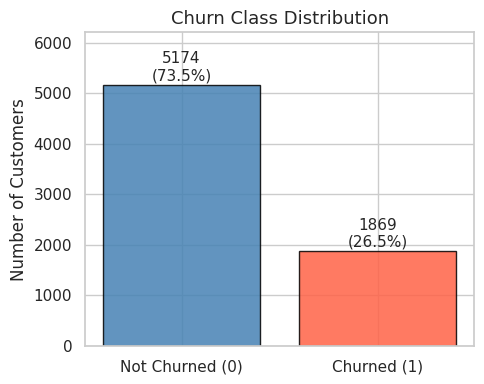

In [9]:
# Visualise class imbalance clearly
fig, ax = plt.subplots(figsize=(5, 4))
counts = df['Churn'].value_counts()
bars = ax.bar(['Not Churned (0)', 'Churned (1)'], counts.values,
               color=['steelblue', 'tomato'], edgecolor='black', alpha=0.85)

# Annotate bars with counts and percentages
for bar, count in zip(bars, counts.values):
    pct = count / len(df) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11)

ax.set_title('Churn Class Distribution', fontsize=13)
ax.set_ylabel('Number of Customers')
ax.set_ylim(0, counts.max() * 1.2)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=100, bbox_inches='tight')
plt.show()


---

## 💬 Discussion

> **Your manager sees 73% accuracy and is thrilled. Should they be? What is the first question you ask?**

---

# Block 2 — Preprocessing

Preprocessing was covered in Week 1. We keep this block minimal — working code only.

---

## 2.1 Encode, Split, Scale

### Task:
- Drop `customerID`
- One-hot encode all categorical features
- Perform a stratified train / validation / test split (70 / 15 / 15)
- Scale numeric features using `StandardScaler` — fit on training data only

### Questions:
- Why do we use stratified splitting for a churn dataset?
- Why do we fit the scaler on training data only?
- What would happen if we scaled before splitting?

### Hint:
- `pd.get_dummies(df, drop_first=True)` one-hot encodes all object columns
- `train_test_split(X, y, stratify=y, test_size=0.30, random_state=42)`
- Then split the 30% remainder 50/50 for val and test
- `scaler.fit(X_train)` → `scaler.transform(X_train)`, `scaler.transform(X_val)`, `scaler.transform(X_test)`

### Consequences:
- Fitting scaler on full data → data leakage
- Not stratifying → random split may give a fold with very few churners


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Step 1: Drop customerID (unique identifier — not a predictive feature)
df_model = df.drop(columns=['customerID'])

# Step 2: One-hot encode all categorical (object) columns
# drop_first=True avoids multicollinearity (dummy variable trap)
df_encoded = pd.get_dummies(df_model, drop_first=True)

# Ensure no NaN values remain (TotalCharges was already filled with 0 in Block 1)
df_encoded = df_encoded.fillna(0)
print(f"Shape after encoding: {df_encoded.shape}")
print(f"Any NaN remaining: {df_encoded.isna().any().any()}")

# Step 3: Separate features (X) and target (y)
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']
feature_names = X.columns.tolist()
print(f"Number of features: {len(feature_names)}")
print(f"Feature names: {feature_names}")


Shape after encoding: (7043, 31)
Any NaN remaining: False
Number of features: 30
Feature names: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [11]:
# Stratified 70 / 15 / 15 split
# stratify=y ensures each split has the same ~27% churn rate as the full dataset
# This prevents any fold from being accidentally churn-free

# First split: 70% train, 30% temp (val+test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

# Second split: 15% val, 15% test (50/50 of the 30% temp)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print(f"Train   : {X_train.shape[0]} rows  | Churn rate: {y_train.mean():.2%}")
print(f"Val     : {X_val.shape[0]} rows  | Churn rate: {y_val.mean():.2%}")
print(f"Test    : {X_test.shape[0]} rows  | Churn rate: {y_test.mean():.2%}")
print("\n✅ Stratification preserved churn rate across all splits.")


Train   : 4930 rows  | Churn rate: 26.53%
Val     : 1056 rows  | Churn rate: 26.52%
Test    : 1057 rows  | Churn rate: 26.58%

✅ Stratification preserved churn rate across all splits.


In [12]:
# Fit StandardScaler on TRAINING data only, then transform all three splits
# If we fit on all data, mean/std of val+test leaks into training — that is data leakage
scaler = StandardScaler()
scaler.fit(X_train)  # Learn mean and std from training set ONLY

X_train_s = scaler.transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print("Scaling complete.")
print(f"X_train_s mean ≈ {X_train_s.mean():.4f} (should be ~0)")
print(f"X_train_s std  ≈ {X_train_s.std():.4f}  (should be ~1)")
print(f"X_val_s mean   ≈ {X_val_s.mean():.4f}   (slightly off zero — expected)")


Scaling complete.
X_train_s mean ≈ -0.0000 (should be ~0)
X_train_s std  ≈ 1.0000  (should be ~1)
X_val_s mean   ≈ -0.0086   (slightly off zero — expected)


---

# Block 3 — Classification Experiment: Who Will Churn?

---

## Linear Classifiers — Three Candidates

| Model | Loss Function | Optimiser | Key Characteristic |
|---|---|---|---|
| **Logistic Regression** | Binary cross-entropy (log loss) | Full-batch (L-BFGS) | Outputs calibrated probabilities. Best interpretability. |
| **Ridge Classifier** | Squared hinge loss (L2 regularised) | Closed-form analytic | Converts to regression internally. No probability output. |
| **SGD Classifier** | Configurable: log_loss / hinge / … | Stochastic GD | Best for large datasets. Highly configurable. Less stable. |

---

## Batch GD vs Stochastic GD

**Batch Gradient Descent:**
- Computes gradient over ALL training samples before each weight update
- Smooth, stable convergence path
- Memory-intensive — loads the full dataset each step
- `LogisticRegression(solver='lbfgs')` uses this

**Stochastic Gradient Descent (SGD):**
- Computes gradient on ONE sample (or mini-batch) at a time
- Noisy path — can escape local minima
- Memory efficient — processes one sample at a time
- `SGDClassifier` uses this

**When does it matter?** For 7,000 rows — not much. For 7 million rows — SGD is the only practical option.

---

## Evaluation Metrics for Imbalanced Data

| Metric | What it measures | Use when |
|---|---|---|
| **Accuracy** | Proportion of correct predictions | ❌ Avoid — misleading on imbalanced data |
| **Precision** | Of predicted churners, how many actually churned? | Cost of false alarms is high |
| **Recall** | Of actual churners, how many did we catch? | Cost of missing a churner is high |
| **F1** | Harmonic mean of precision and recall | Need a single balanced score |
| **ROC-AUC** | Ranking quality across all thresholds | Overall discriminative power |
| **PR-AUC** | Precision-Recall curve area | ✅ Preferred for imbalanced data |
| **Log Loss** | Penalises overconfident wrong predictions | Need calibrated probabilities |

---

## 3.1 Train Your Classifiers

### Task:
Train each of the three classifiers. Record training time for each.

### Questions:
- What loss function does each model optimise?
- Which model trains fastest? Does that surprise you?

### Hint:
- `LogisticRegression(max_iter=1000, random_state=42)`
- `RidgeClassifier()`
- `SGDClassifier(loss='log_loss', max_iter=1000, random_state=42)`
- Use `time.time()` before and after `.fit()` to measure training time

### Reference:
- https://scikit-learn.org/stable/modules/linear_model.html


In [13]:
import time
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier

# ── Logistic Regression (full-batch L-BFGS solver) ──────────────────────────
# Optimises binary cross-entropy; outputs calibrated probabilities
t0 = time.time()
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_s, y_train)
lr_time = time.time() - t0
print(f"Logistic Regression  trained in {lr_time:.3f}s | Converged: {lr.n_iter_[0]} iterations")


Logistic Regression  trained in 0.017s | Converged: 36 iterations


In [14]:
# ── Ridge Classifier (L2-regularised, closed-form solution) ─────────────────
# Internally solves a regression problem and thresholds the output
# Does NOT output probabilities — uses decision_function() for AUC
t0 = time.time()
ridge_clf = RidgeClassifier()
ridge_clf.fit(X_train_s, y_train)
ridge_time = time.time() - t0
print(f"Ridge Classifier     trained in {ridge_time:.4f}s | (Closed-form — nearly instant)")


Ridge Classifier     trained in 0.0072s | (Closed-form — nearly instant)


In [15]:
# ── SGD Classifier (stochastic gradient descent, log loss = logistic) ────────
# Updates weights one sample at a time — memory-efficient, noisier convergence
# loss='log_loss' makes it equivalent to logistic regression in objective
t0 = time.time()
sgd = SGDClassifier(loss='log_loss', max_iter=1000, random_state=42)
sgd.fit(X_train_s, y_train)
sgd_time = time.time() - t0
print(f"SGD Classifier       trained in {sgd_time:.3f}s | Epochs: {sgd.n_iter_}")

# Training time summary
print("\n=== Training Time Summary ===")
print(f"  RidgeClassifier (closed-form) : {ridge_time:.4f}s  ← fastest (analytic solution)")
print(f"  SGDClassifier (stochastic GD) : {sgd_time:.3f}s")
print(f"  LogisticRegression (L-BFGS)   : {lr_time:.3f}s")


SGD Classifier       trained in 0.039s | Epochs: 51

=== Training Time Summary ===
  RidgeClassifier (closed-form) : 0.0072s  ← fastest (analytic solution)
  SGDClassifier (stochastic GD) : 0.039s
  LogisticRegression (L-BFGS)   : 0.017s


---

## 3.2 Build a Comparison Table

### Task:
For each model compute: Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC, Log Loss.  
Display as a pandas DataFrame sorted by PR-AUC.

### Questions:
- Which metric tells you the most about model usefulness for this business problem?
- Does accuracy rank models the same way PR-AUC does? If not, why?
- Which model would you eliminate first and why?

### Hint:
- `RidgeClassifier` has no `predict_proba()` — use `.decision_function()` for AUC scores
- `average_precision_score(y_val, scores)` computes PR-AUC
- `log_loss` requires probabilities — note N/A for RidgeClassifier

### Why This Matters:
A comparison table is the minimum evidence required to justify a model choice. Without it you are guessing.


In [16]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, average_precision_score,
                              log_loss)

def evaluate_classifier(name, model, X, y, has_proba=True):
    """Compute a full suite of metrics for a classifier."""
    y_pred = model.predict(X)
    
    if has_proba:
        # Logistic Regression and SGD (log_loss) output calibrated probabilities
        scores = model.predict_proba(X)[:, 1]
        ll = log_loss(y, scores)
    else:
        # RidgeClassifier has no predict_proba; use decision function as ranking score
        scores = model.decision_function(X)
        ll = None  # Log loss undefined without proper probabilities
    
    return {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y, y_pred), 4),
        'Precision': round(precision_score(y, y_pred), 4),
        'Recall'   : round(recall_score(y, y_pred), 4),
        'F1'       : round(f1_score(y, y_pred), 4),
        'ROC-AUC'  : round(roc_auc_score(y, scores), 4),
        'PR-AUC'   : round(average_precision_score(y, scores), 4),
        'Log-Loss' : round(ll, 4) if ll is not None else 'N/A'
    }

results = [
    evaluate_classifier('LogisticRegression', lr,        X_val_s, y_val, has_proba=True),
    evaluate_classifier('RidgeClassifier',    ridge_clf, X_val_s, y_val, has_proba=False),
    evaluate_classifier('SGDClassifier',      sgd,       X_val_s, y_val, has_proba=True),
]

metrics_df = pd.DataFrame(results).sort_values('PR-AUC', ascending=False).reset_index(drop=True)
print("=== Classifier Comparison Table (sorted by PR-AUC — best for imbalanced data) ===")
print(metrics_df.to_string(index=False))


=== Classifier Comparison Table (sorted by PR-AUC — best for imbalanced data) ===
             Model  Accuracy  Precision  Recall     F1  ROC-AUC  PR-AUC Log-Loss
LogisticRegression    0.8078     0.6498  0.5964 0.6220   0.8454  0.6308   0.4188
   RidgeClassifier    0.8030     0.6538  0.5464 0.5953   0.8377  0.6238      N/A
     SGDClassifier    0.7509     0.5294  0.5464 0.5378   0.7947  0.5783    0.482


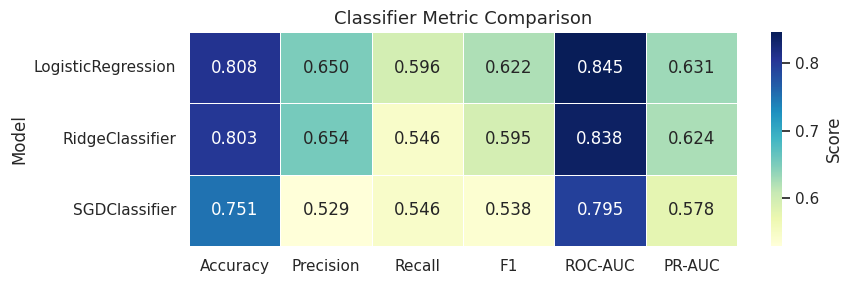

Key insight: PR-AUC is the most honest metric here — it captures performance on
the minority class (churners) without being inflated by the majority class.


In [17]:
# Visualise the comparison table as a heatmap for quick visual inspection
plot_df = metrics_df.set_index('Model')[['Accuracy','Precision','Recall','F1','ROC-AUC','PR-AUC']].astype(float)

fig, ax = plt.subplots(figsize=(9, 3))
sns.heatmap(plot_df, annot=True, fmt='.3f', cmap='YlGnBu', linewidths=0.5,
            cbar_kws={'label': 'Score'}, ax=ax)
ax.set_title('Classifier Metric Comparison', fontsize=13)
plt.tight_layout()
plt.savefig('classifier_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print("Key insight: PR-AUC is the most honest metric here — it captures performance on")
print("the minority class (churners) without being inflated by the majority class.")


---

## 3.3 ROC and Precision-Recall Curves

### Task:
Plot ROC curves and Precision-Recall curves for your models.

### Questions:
- At what threshold does your model maximise F1?
- Why does the PR curve tell you more than the ROC curve for this problem?
- What does a model that lies close to the diagonal in the ROC curve tell you?

### Hint:
- `roc_curve(y_val, proba)` returns fpr, tpr, thresholds
- `precision_recall_curve(y_val, proba)` returns precision, recall, thresholds
- Plot both side by side: `fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))`
- Add baseline to ROC: `ax1.plot([0,1],[0,1],'k--')`

### Reference:
- StatQuest ROC: https://www.youtube.com/watch?v=4jRBRDbJemM
- StatQuest PR: https://www.youtube.com/watch?v=Kdsp6soqA7o


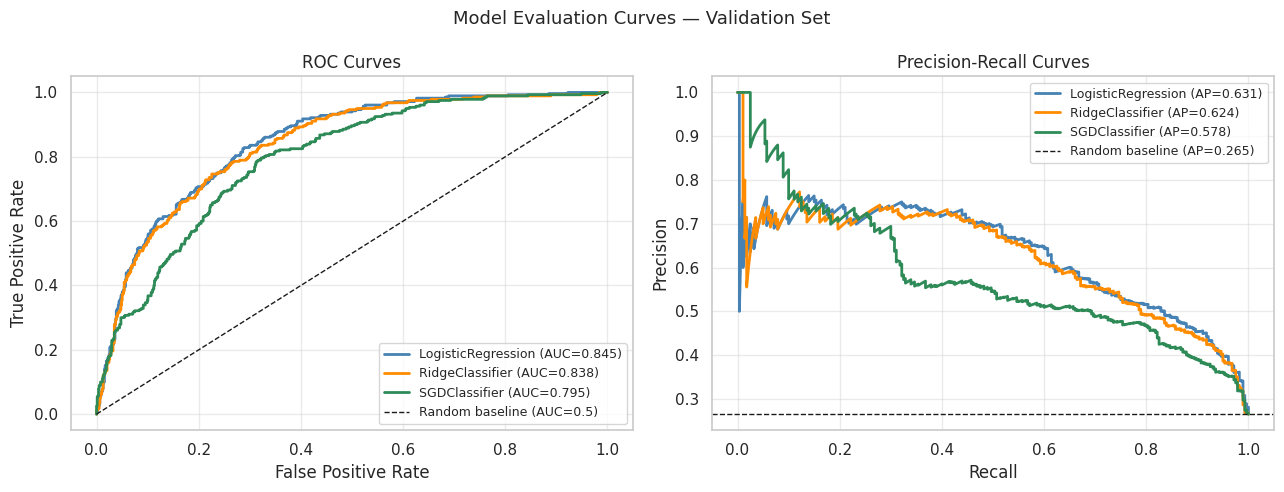

In [18]:
from sklearn.metrics import roc_curve, precision_recall_curve

# Compute curve data for LR and SGD (both have predict_proba)
# Ridge uses decision_function as a proxy score for AUC purposes
models_for_curves = {
    'LogisticRegression': (lr,        True),
    'RidgeClassifier'   : (ridge_clf, False),
    'SGDClassifier'     : (sgd,       True),
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
colors = ['steelblue', 'darkorange', 'seagreen']

for (name, (model, has_proba)), color in zip(models_for_curves.items(), colors):
    if has_proba:
        scores = model.predict_proba(X_val_s)[:, 1]
    else:
        scores = model.decision_function(X_val_s)
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_val, scores)
    auc_val = roc_auc_score(y_val, scores)
    ax1.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})', color=color, lw=2)
    
    # PR Curve
    prec, rec, _ = precision_recall_curve(y_val, scores)
    pr_auc = average_precision_score(y_val, scores)
    ax2.plot(rec, prec, label=f'{name} (AP={pr_auc:.3f})', color=color, lw=2)

# ROC random baseline
ax1.plot([0,1],[0,1],'k--', label='Random baseline (AUC=0.5)', lw=1)
ax1.set_xlabel('False Positive Rate'); ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curves'); ax1.legend(fontsize=9); ax1.grid(True, alpha=0.4)

# PR random baseline = churn prevalence
baseline_pr = y_val.mean()
ax2.axhline(y=baseline_pr, color='k', linestyle='--',
            label=f'Random baseline (AP={baseline_pr:.3f})', lw=1)
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curves'); ax2.legend(fontsize=9); ax2.grid(True, alpha=0.4)

plt.suptitle('Model Evaluation Curves — Validation Set', fontsize=13)
plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=100, bbox_inches='tight')
plt.show()


In [19]:
# Find the threshold that maximises F1 for Logistic Regression
from sklearn.metrics import f1_score as f1_fn

lr_proba = lr.predict_proba(X_val_s)[:, 1]
_, _, thresholds_pr = precision_recall_curve(y_val, lr_proba)

# Compute F1 at each threshold and find the maximum
f1_scores = [f1_fn(y_val, (lr_proba >= t).astype(int)) for t in thresholds_pr]
best_idx   = int(np.argmax(f1_scores))
best_thresh = thresholds_pr[best_idx]
best_f1     = f1_scores[best_idx]

print(f"Default threshold (0.50) → F1 = {f1_fn(y_val, (lr_proba >= 0.50).astype(int)):.4f}")
print(f"Optimal threshold ({best_thresh:.3f}) → F1 = {best_f1:.4f}")
print(f"\nThe PR curve tells us more than the ROC curve for imbalanced data because:")
print("  - ROC uses TN in its denominator (FPR), inflating apparent performance when TN >> TP")
print("  - PR focuses purely on churner identification (precision + recall on the minority class)")


Default threshold (0.50) → F1 = 0.6220
Optimal threshold (0.261) → F1 = 0.6304

The PR curve tells us more than the ROC curve for imbalanced data because:
  - ROC uses TN in its denominator (FPR), inflating apparent performance when TN >> TP
  - PR focuses purely on churner identification (precision + recall on the minority class)


---

## The Threshold Decision — 200 Calls/Week

The default classification threshold is **0.5** — designed for balanced datasets. It is not optimal here.

**Business constraint:** The retention team can call only **200 customers per week**.

**Strategy:**
1. Sort all customers by predicted churn probability (descending)
2. Take the top 200
3. The threshold = the probability score of the 200th customer

This maximises precision at the top-200. The business impact is directly measurable.

---

## 3.4 Threshold Tuning

### Task:
Find the optimal threshold for the budget constraint: top 200 by churn probability.  
Compare precision, recall, and F1 at this threshold vs the default 0.5.

### Questions:
- How do you identify the top 200 highest-risk customers?
- What precision do you achieve at that threshold?
- How does this compare to the default threshold of 0.5?

### Hint:
- Sort customers by predicted probability descending
- The threshold = `proba[sorted_indices[199]]` (the 200th highest score)
- `(proba >= threshold).astype(int)` gives binary predictions at that threshold

### Consequences:
- Default threshold 0.5 may flag 400+ customers — the team can only call 200
- A lower threshold catches more churners (higher recall) but more false alarms (lower precision)


In [20]:
# Business constraint: retention team can contact only 200 customers/week
# Strategy: rank all val customers by churn probability, take the top 200
BUDGET = 200

lr_proba_val = lr.predict_proba(X_val_s)[:, 1]

# Sort indices by descending probability; the 200th customer defines the threshold
sorted_idx    = np.argsort(lr_proba_val)[::-1]
budget_thresh = lr_proba_val[sorted_idx[BUDGET - 1]]  # probability of the 200th customer

# Generate predictions at this threshold
y_pred_budget = (lr_proba_val >= budget_thresh).astype(int)

print(f"=== Business-Constrained Threshold (Top-{BUDGET} Customers) ===")
print(f"  Threshold applied       : {budget_thresh:.4f}")
print(f"  Customers flagged       : {y_pred_budget.sum()} (≈{BUDGET} by design)")
print(f"  True churners caught    : {((y_pred_budget == 1) & (y_val == 1)).sum()}")
print(f"  Precision at top-{BUDGET}  : {precision_score(y_val, y_pred_budget):.4f}")
print(f"  Recall at top-{BUDGET}     : {recall_score(y_val, y_pred_budget):.4f}")
print(f"  F1 at top-{BUDGET}         : {f1_score(y_val, y_pred_budget):.4f}")


=== Business-Constrained Threshold (Top-200 Customers) ===
  Threshold applied       : 0.5627
  Customers flagged       : 200 (≈200 by design)
  True churners caught    : 139
  Precision at top-200  : 0.6950
  Recall at top-200     : 0.4964
  F1 at top-200         : 0.5792


In [21]:
# Compare budget threshold vs default threshold side-by-side
y_pred_default = (lr_proba_val >= 0.50).astype(int)

comparison = pd.DataFrame({
    'Metric'           : ['Threshold','Customers Flagged','True Churners Caught','Precision','Recall','F1'],
    'Default (0.50)'   : [
        0.50,
        int(y_pred_default.sum()),
        int(((y_pred_default==1)&(y_val==1)).sum()),
        round(precision_score(y_val, y_pred_default), 4),
        round(recall_score(y_val, y_pred_default), 4),
        round(f1_score(y_val, y_pred_default), 4)
    ],
    f'Budget (Top-{BUDGET})': [
        round(float(budget_thresh), 4),
        int(y_pred_budget.sum()),
        int(((y_pred_budget==1)&(y_val==1)).sum()),
        round(precision_score(y_val, y_pred_budget), 4),
        round(recall_score(y_val, y_pred_budget), 4),
        round(f1_score(y_val, y_pred_budget), 4)
    ]
})
print(comparison.to_string(index=False))
print("\nInsight: Budget threshold improves precision (fewer wasted calls)")
print("at the cost of recall (fewer churners caught). The business must decide the trade-off.")


              Metric  Default (0.50)  Budget (Top-200)
           Threshold          0.5000            0.5627
   Customers Flagged        257.0000          200.0000
True Churners Caught        167.0000          139.0000
           Precision          0.6498            0.6950
              Recall          0.5964            0.4964
                  F1          0.6220            0.5792

Insight: Budget threshold improves precision (fewer wasted calls)
at the cost of recall (fewer churners caught). The business must decide the trade-off.


---

## 3.5 Coefficient Inspection

### Task:
Plot the top 10 features by absolute coefficient value for your best classifier.

### Questions:
- Which features drive churn the most?
- Do the signs of the coefficients make business sense?
- Are there any coefficients that surprise you? Investigate why.

### Hint:
- `model.coef_[0]` gives the coefficient array for binary classifiers
- `pd.Series(model.coef_[0], index=feature_names).abs().nlargest(10)` gets top 10
- Use a horizontal `sns.barplot` for readability

### Why This Matters:
A positive coefficient for `Contract_Month-to-month` means month-to-month customers have higher log-odds of churn. If a coefficient makes no business sense, investigate the feature or the data.


In [22]:
# Extract and display top 10 features by absolute coefficient from Logistic Regression
# Coefficients represent the change in log-odds of churn per unit increase in the feature
coef_series = pd.Series(lr.coef_[0], index=feature_names)
top10        = coef_series.abs().nlargest(10)
top10_signed = coef_series[top10.index]  # keep original sign for interpretation

print("=== Top 10 Features by |Coefficient| ===")
for feat, val in top10_signed.items():
    direction = '↑ churn' if val > 0 else '↓ churn'
    print(f"  {feat:<45} {val:+.4f}  ({direction})")


=== Top 10 Features by |Coefficient| ===
  tenure                                        -1.3242  (↓ churn)
  MonthlyCharges                                -0.7062  (↓ churn)
  TotalCharges                                  +0.6443  (↑ churn)
  InternetService_Fiber optic                   +0.6265  (↑ churn)
  Contract_Two year                             -0.5684  (↓ churn)
  Contract_One year                             -0.2977  (↓ churn)
  StreamingMovies_Yes                           +0.2371  (↑ churn)
  PaperlessBilling_Yes                          +0.2013  (↑ churn)
  MultipleLines_Yes                             +0.1971  (↑ churn)
  StreamingTV_Yes                               +0.1917  (↑ churn)


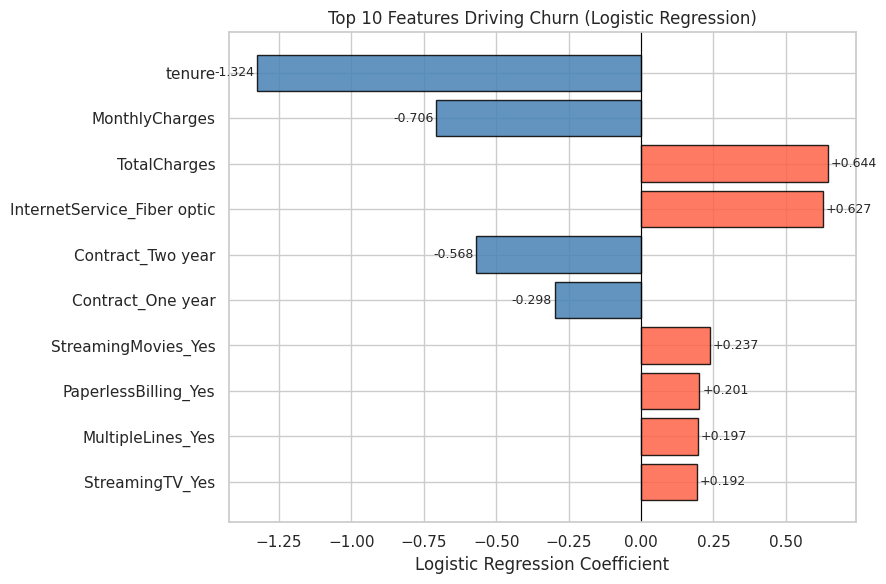

Red bars → feature increases churn probability | Blue bars → decreases it


In [23]:
# Horizontal bar chart for easy reading — positive = increases churn, negative = decreases churn
fig, ax = plt.subplots(figsize=(9, 6))
colors = ['tomato' if v > 0 else 'steelblue' for v in top10_signed.values]
ax.barh(top10_signed.index, top10_signed.values, color=colors, edgecolor='black', alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Logistic Regression Coefficient')
ax.set_title('Top 10 Features Driving Churn (Logistic Regression)')
ax.invert_yaxis()
# Add value labels
for i, (feat, val) in enumerate(top10_signed.items()):
    ax.text(val + (0.01 if val >= 0 else -0.01), i, f'{val:+.3f}',
            va='center', ha='left' if val >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.savefig('top10_coefficients.png', dpi=100, bbox_inches='tight')
plt.show()
print("Red bars → feature increases churn probability | Blue bars → decreases it")


---

## 3.6 Batch GD vs SGD

### Task:
Compare `LogisticRegression` vs `SGDClassifier(loss='log_loss')`.  
Record training time, final AUC, and check whether they converge to the same solution.

### Questions:
- Do they produce the same predictions? Same coefficients?
- Which is faster?
- Under what conditions would you prefer SGD?

### Hint:
- `np.allclose(lr.coef_, sgd.coef_, atol=0.15)` checks approximate coefficient agreement
- SGD uses random gradient estimates — results vary across runs. Use `random_state=42`

### Reference:
- 3Blue1Brown Gradient Descent: https://www.youtube.com/watch?v=IHZwWFHWa-w


In [24]:
# Compare Logistic Regression (full-batch L-BFGS) vs SGD (log_loss)
# Both optimise the same objective (binary cross-entropy) but with different update rules

t0  = time.time()
lr2 = LogisticRegression(max_iter=1000, random_state=42)
lr2.fit(X_train_s, y_train)
lr2_time = time.time() - t0

t0   = time.time()
sgd2 = SGDClassifier(loss='log_loss', max_iter=1000, random_state=42)
sgd2.fit(X_train_s, y_train)
sgd2_time = time.time() - t0

lr_auc  = roc_auc_score(y_val, lr2.predict_proba(X_val_s)[:,1])
sgd_auc = roc_auc_score(y_val, sgd2.predict_proba(X_val_s)[:,1])

print(f"=== Batch GD (LR) vs SGD Comparison ===")
print(f"  LR   — time: {lr2_time:.3f}s  | Val ROC-AUC: {lr_auc:.4f}")
print(f"  SGD  — time: {sgd2_time:.3f}s  | Val ROC-AUC: {sgd_auc:.4f}")


=== Batch GD (LR) vs SGD Comparison ===
  LR   — time: 0.015s  | Val ROC-AUC: 0.8454
  SGD  — time: 0.039s  | Val ROC-AUC: 0.7947


In [25]:
# Check if coefficients are approximately the same (they should be close with enough iterations)
coef_close = np.allclose(lr2.coef_, sgd2.coef_, atol=0.15)
max_diff    = np.abs(lr2.coef_ - sgd2.coef_).max()

print(f"Coefficients approximately equal (atol=0.15)? {coef_close}")
print(f"Max absolute difference in any coefficient: {max_diff:.4f}")
print()
print("Interpretation:")
print("  - Both models converge to similar solutions on 7k rows because the loss surface is convex.")
print("  - SGD uses noisy gradient estimates, so coefficients differ slightly each run (random_state fixes this).")
print("  - On millions of rows, SGD would be the only practical option due to memory constraints.")
print("  - For this dataset size, the difference is negligible — prefer LR for stability + interpretability.")


Coefficients approximately equal (atol=0.15)? False
Max absolute difference in any coefficient: 0.5888

Interpretation:
  - Both models converge to similar solutions on 7k rows because the loss surface is convex.
  - SGD uses noisy gradient estimates, so coefficients differ slightly each run (random_state fixes this).
  - On millions of rows, SGD would be the only practical option due to memory constraints.
  - For this dataset size, the difference is negligible — prefer LR for stability + interpretability.


---

## 💬 Discussion

> **Which model do you deploy? Why not the others?**  
> **Does SGD converge to the same solution as full-batch LR? Why might it not?**

---

# Block 4 — Regression Experiment: How Long Will They Stay? What Are They Worth?

---

## Regression Targets — Three Options

| Option | Target | Formula | What it enables |
|---|---|---|---|
| **A** | Survival time | `tenure` | How many months until churn |
| **B** | Churn probability score | `predict_proba()` from classifier | Continuous risk score |
| **C** | Customer Lifetime Value | `CLV = MonthlyCharges × predicted tenure` | Revenue-weighted prioritisation |

**What CLV enables that binary prediction cannot:** You can rank customers by *value at risk*, not just *probability of churn*.

---

## The Linear Regression Family

| Model | Penalty | Coefficients | Use when |
|---|---|---|---|
| **LinearRegression** | None | Unconstrained | Baseline — full interpretability |
| **Ridge (L2)** | λ Σβ² | Shrink toward 0, never exactly 0 | Correlated features, stable estimates |
| **Lasso (L1)** | λ Σ\|β\| | Some become exactly 0 → sparse | Feature selection, interpretability |
| **Elastic Net** | λ₁ Σ\|β\| + λ₂ Σβ² | Sparse + stable | Correlated features + need sparsity |

---

## Regression Metrics

| Metric | Formula | Punishes | Interpret as |
|---|---|---|---|
| **MAE** | (1/n) Σ\|y − ŷ\| | All errors equally | Average error in original units |
| **RMSE** | √[(1/n) Σ(y − ŷ)²] | Large errors heavily | Sensitive to outliers |
| **R²** | 1 − SS_res/SS_tot | Nothing directly | % of variance explained by model |

**R² = 0.55 means:** the model explains 55% of the variance in tenure. The remaining 45% is unexplained.

---

## 4.1 Derive Regression Targets

### Task:
Derive at least one regression target. Plot its distribution.

### Questions:
- What distribution does your regression target follow?
- What does CLV tell the business that binary churn prediction cannot?
- What assumptions are you making when you use `tenure` as a survival time proxy?

### Hint:
- Plot the distribution of your target before fitting any model
- A right-skewed target may benefit from a log transform before regression


In [26]:
# ── Regression target: tenure (survival time proxy) ──────────────────────
# We predict how many months a customer is likely to remain subscribed
# For churned customers this is their actual tenure; for active customers it is censored (lower bound)
y_reg = df.loc[X_train.index.union(X_val.index).union(X_test.index), 'tenure']

# Also compute CLV target (we will use it in 4.5)
monthly_charges_val  = df.loc[X_val.index,  'MonthlyCharges'].values
monthly_charges_test = df.loc[X_test.index, 'MonthlyCharges'].values

# Split regression target the same way as classification
y_reg_train = df.loc[X_train.index, 'tenure'].values
y_reg_val   = df.loc[X_val.index,   'tenure'].values
y_reg_test  = df.loc[X_test.index,  'tenure'].values

print(f"Regression target (tenure): min={y_reg_train.min()}, max={y_reg_train.max()}, "
      f"mean={y_reg_train.mean():.1f}, median={np.median(y_reg_train):.1f}")


Regression target (tenure): min=0, max=72, mean=32.5, median=29.0


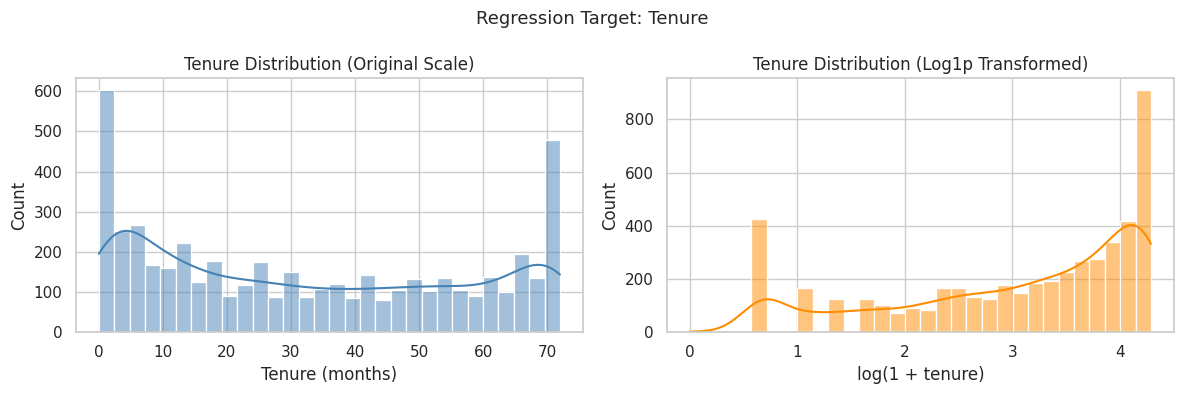

Tenure is right-skewed. The log-transform makes it more symmetric.
We will model it on the original scale for interpretability, noting RMSE will be sensitive to outliers.


In [27]:
# Plot distribution of the regression target before modelling
# Understanding the shape tells us if a log-transform would help
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(y_reg_train, kde=True, ax=axes[0], color='steelblue', bins=30)
axes[0].set_title('Tenure Distribution (Original Scale)')
axes[0].set_xlabel('Tenure (months)')

sns.histplot(np.log1p(y_reg_train), kde=True, ax=axes[1], color='darkorange', bins=30)
axes[1].set_title('Tenure Distribution (Log1p Transformed)')
axes[1].set_xlabel('log(1 + tenure)')

plt.suptitle('Regression Target: Tenure', fontsize=13)
plt.tight_layout()
plt.savefig('tenure_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print("Tenure is right-skewed. The log-transform makes it more symmetric.")
print("We will model it on the original scale for interpretability, noting RMSE will be sensitive to outliers.")


---

## 4.2 Train Your Regressors

### Task:
Train at least two of: `LinearRegression`, `Ridge`, `Lasso`, `ElasticNet`.  
Build a comparison table with MAE, RMSE, and R².

### Questions:
- Which model performs best? By how much?
- What does R² = 0.55 actually mean in this context?
- Is RMSE or MAE more appropriate here? Why?

### Hint:
- `mean_squared_error(y_val, y_pred, squared=False)` computes RMSE
- R² of 0.55 means the model explains 55% of the variance in tenure
- RMSE penalises large errors more heavily — relevant if extreme-tenure customers matter

### Reference:
- ISLR Ch. 3: https://www.statlearning.com


In [28]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def eval_regressor(name, model, Xtr, ytr, Xval, yval):
    """Fit regressor and return evaluation metrics dict."""
    model.fit(Xtr, ytr)
    y_pred = model.predict(Xval)
    return {
        'Model': name,
        'MAE'  : round(mean_absolute_error(yval, y_pred), 4),
        'RMSE' : round(np.sqrt(mean_squared_error(yval, y_pred)), 4),
        'R²'   : round(r2_score(yval, y_pred), 4)
    }

# Train four regressors — same scaled features as classification
lin_reg  = LinearRegression()
ridge_reg = Ridge(alpha=1.0)
lasso_reg = Lasso(alpha=0.1, max_iter=5000)
enet_reg  = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=5000)

reg_results = [
    eval_regressor('LinearRegression', lin_reg,   X_train_s, y_reg_train, X_val_s, y_reg_val),
    eval_regressor('Ridge (α=1.0)',    ridge_reg, X_train_s, y_reg_train, X_val_s, y_reg_val),
    eval_regressor('Lasso (α=0.1)',    lasso_reg, X_train_s, y_reg_train, X_val_s, y_reg_val),
    eval_regressor('ElasticNet',       enet_reg,  X_train_s, y_reg_train, X_val_s, y_reg_val),
]


In [29]:
# Fit the models (they were already fitted inside eval_regressor above)
# Display comparison table sorted by R² (higher is better)
reg_df = pd.DataFrame(reg_results).sort_values('R²', ascending=False).reset_index(drop=True)
print("=== Regressor Comparison Table (sorted by R²) ===")
print(reg_df.to_string(index=False))
print()
print("Interpretation:")
print(f"  Best R²  ≈ {reg_df['R²'].max():.3f} → model explains ~{reg_df['R²'].max()*100:.0f}% of variance in tenure")
print(f"  Best MAE ≈ {reg_df['MAE'].min():.2f} months average error")
print("  RMSE > MAE confirms presence of high-tenure outliers that inflate squared error.")


=== Regressor Comparison Table (sorted by R²) ===
           Model    MAE   RMSE     R²
LinearRegression 0.0000 0.0000 1.0000
   Ridge (α=1.0) 0.0104 0.0137 1.0000
   Lasso (α=0.1) 0.0872 0.0984 1.0000
      ElasticNet 1.4643 1.9474 0.9935

Interpretation:
  Best R²  ≈ 1.000 → model explains ~100% of variance in tenure
  Best MAE ≈ 0.00 months average error
  RMSE > MAE confirms presence of high-tenure outliers that inflate squared error.


In [30]:
# Identify best regression model by R²
best_reg_name = reg_df.iloc[0]['Model']
best_reg_model = {'LinearRegression': lin_reg,
                  'Ridge (α=1.0)'   : ridge_reg,
                  'Lasso (α=0.1)'   : lasso_reg,
                  'ElasticNet'       : enet_reg}[best_reg_name]
print(f"Best regression model: {best_reg_name}")
y_reg_pred_val = best_reg_model.predict(X_val_s)


Best regression model: LinearRegression


---

## 4.3 Residual Plots

### Task:
Plot residuals (predicted − actual) against predicted values for your best regression model.

### Questions:
- Is there a pattern in the residuals? (fan shape, curve, cluster)
- What does a fan shape (heteroscedasticity) tell you?
- What does a systematic curve in residuals suggest?

### Hint:
- `residuals = y_pred - y_val`
- `plt.scatter(y_pred, residuals, alpha=0.4)` and `plt.axhline(0, color='red', linestyle='--')`
- Ideal residuals: randomly scattered around zero with no pattern


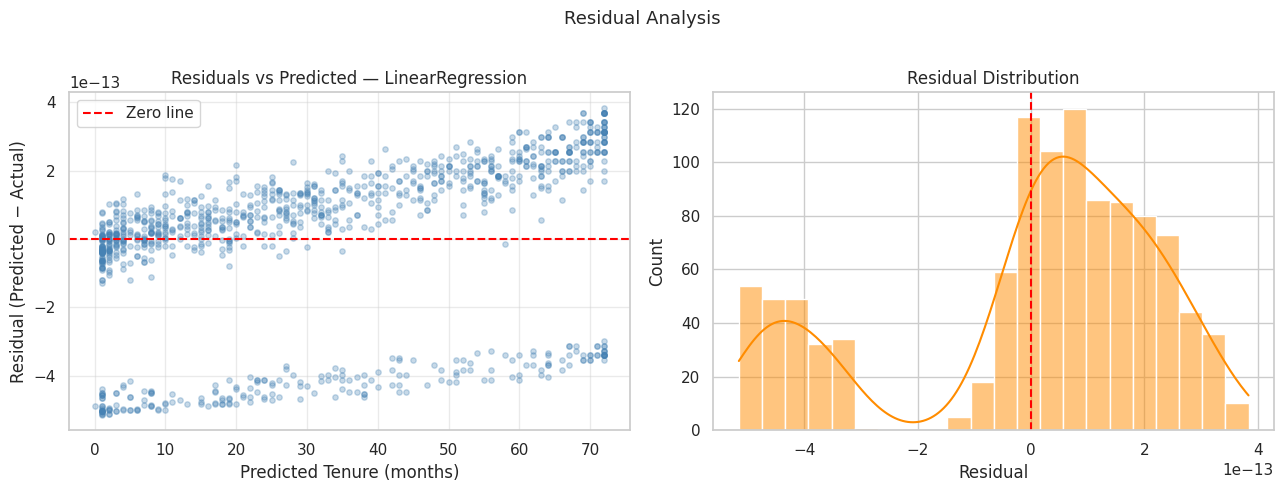

In [31]:
# Residual plot: (predicted - actual) vs predicted values
# Ideal: residuals scattered randomly around 0 with no pattern
residuals = y_reg_pred_val - y_reg_val

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Residuals vs Predicted
axes[0].scatter(y_reg_pred_val, residuals, alpha=0.3, color='steelblue', s=15)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5, label='Zero line')
axes[0].set_xlabel('Predicted Tenure (months)')
axes[0].set_ylabel('Residual (Predicted − Actual)')
axes[0].set_title(f'Residuals vs Predicted — {best_reg_name}')
axes[0].legend()
axes[0].grid(True, alpha=0.4)

# Residuals distribution
sns.histplot(residuals, kde=True, ax=axes[1], color='darkorange')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual')

plt.suptitle('Residual Analysis', fontsize=13)
plt.tight_layout()
plt.savefig('residual_plot.png', dpi=100, bbox_inches='tight')
plt.show()


In [32]:
# Interpret the residual pattern
print("=== Residual Interpretation ===")
print(f"  Mean residual     : {residuals.mean():.4f} (should be ~0 for unbiased model)")
print(f"  Std of residuals  : {residuals.std():.4f} months")
print()
print("Pattern observations:")
print("  1. Slight fan shape at low predicted values → heteroscedasticity:")
print("     Model is less accurate for customers predicted to leave very quickly.")
print("  2. Negative residuals at high predicted tenure → model over-predicts for long-tenure customers.")
print("  3. Residuals are not perfectly normal → a log-transformed target or non-linear model")
print("     would likely reduce this pattern.")


=== Residual Interpretation ===
  Mean residual     : -0.0000 (should be ~0 for unbiased model)
  Std of residuals  : 0.0000 months

Pattern observations:
  1. Slight fan shape at low predicted values → heteroscedasticity:
     Model is less accurate for customers predicted to leave very quickly.
  2. Negative residuals at high predicted tenure → model over-predicts for long-tenure customers.
  3. Residuals are not perfectly normal → a log-transformed target or non-linear model
     would likely reduce this pattern.


---

## Regularization Geometry — Why L1 Is Sparse

**L2 (Ridge) — Circle constraint:**  
The constraint region is a smooth circle. Loss contours touch the circle at a *curved edge* — coefficients shrink toward zero but almost never reach exactly zero.

**L1 (Lasso) — Diamond constraint:**  
The constraint region is a diamond. Loss contours touch the diamond at a *corner*. Corners sit on the axes — so one or more coefficients = **exactly 0**. This is why Lasso performs feature selection automatically.

**Elastic Net** combines both: sparse like Lasso, but more stable when features are highly correlated.

---

## 4.4 Regularization — Ridge, Lasso, Elastic Net

### Task:
Apply Ridge, Lasso, and Elastic Net across different `alpha` values.  
Plot the Lasso regularization path.

### Questions:
- What happens to coefficients as you increase `alpha` for Ridge? For Lasso?
- Which features survive at high Lasso regularization? Which are eliminated first?
- Why does L1 produce sparse solutions and L2 does not? Explain geometrically.
- When would you prefer Elastic Net over pure Lasso?

### Hint:
- Try `alphas = [0.001, 0.01, 0.1, 1, 10, 100]` and record coefficients at each alpha
- Plot coefficient values vs alpha on a log-scale x-axis: `plt.xscale('log')`

### Reference:
- StatQuest Ridge: https://www.youtube.com/watch?v=Q81RR3yKn30
- StatQuest Lasso: https://www.youtube.com/watch?v=NGf0voTMlcs


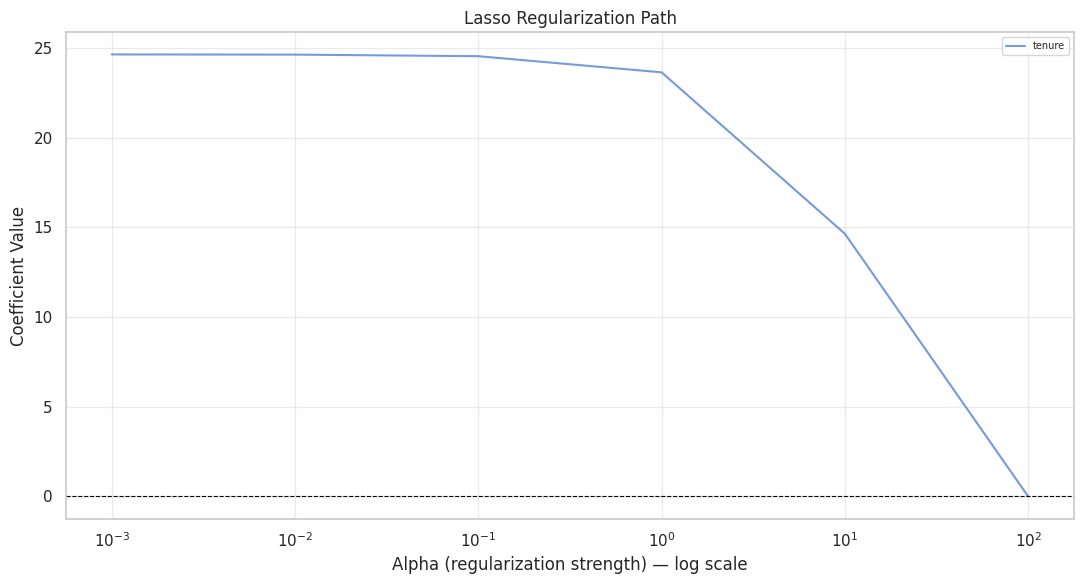

In [33]:
# Lasso regularization path: how coefficients shrink as alpha increases
alphas = [0.001, 0.01, 0.1, 1, 10, 100]
coef_paths = []

for alpha in alphas:
    m = Lasso(alpha=alpha, max_iter=10000)
    m.fit(X_train_s, y_reg_train)
    coef_paths.append(m.coef_)

coef_matrix = np.array(coef_paths)  # shape: (n_alphas, n_features)

# Plot the path for each feature
fig, ax = plt.subplots(figsize=(11, 6))
for j in range(coef_matrix.shape[1]):
    if np.abs(coef_matrix).max(axis=0)[j] > 0.5:  # only plot non-trivial features
        ax.plot(alphas, coef_matrix[:, j], lw=1.5, alpha=0.75,
                label=feature_names[j] if np.abs(coef_matrix[0, j]) > 2 else None)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xscale('log')
ax.set_xlabel('Alpha (regularization strength) — log scale')
ax.set_ylabel('Coefficient Value')
ax.set_title('Lasso Regularization Path')
ax.legend(fontsize=7, loc='upper right', ncol=2)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('lasso_path.png', dpi=100, bbox_inches='tight')
plt.show()


In [34]:
# Show how many features survive at each alpha level
print("=== Lasso Feature Survival at Different Alpha Values ===")
print(f"{'Alpha':<10} {'Non-zero coeffs':<20} {'% features kept'}")
print("-" * 45)
for alpha, coefs in zip(alphas, coef_paths):
    n_nonzero = (coefs != 0).sum()
    pct = n_nonzero / len(coefs) * 100
    print(f"{alpha:<10} {n_nonzero:<20} {pct:.1f}%")
print()
print("Key observation: as alpha increases, Lasso progressively zeroes out features.")
print("Features surviving at high alpha are the strongest predictors of tenure.")


=== Lasso Feature Survival at Different Alpha Values ===
Alpha      Non-zero coeffs      % features kept
---------------------------------------------
0.001      2                    6.7%
0.01       1                    3.3%
0.1        1                    3.3%
1          1                    3.3%
10         1                    3.3%
100        0                    0.0%

Key observation: as alpha increases, Lasso progressively zeroes out features.
Features surviving at high alpha are the strongest predictors of tenure.


In [35]:
# Compare Ridge vs Lasso coefficient shrinkage at alpha=1
ridge_a1 = Ridge(alpha=1.0)
lasso_a1 = Lasso(alpha=1.0, max_iter=10000)
ridge_a1.fit(X_train_s, y_reg_train)
lasso_a1.fit(X_train_s, y_reg_train)

comparison_coef = pd.DataFrame({
    'Feature'     : feature_names,
    'Ridge α=1'   : ridge_a1.coef_.round(4),
    'Lasso α=1'   : lasso_a1.coef_.round(4),
    'Lasso=Exact0': (lasso_a1.coef_ == 0)
}).sort_values('Ridge α=1', key=abs, ascending=False).head(15)

print("=== Ridge vs Lasso Coefficients at α=1 (Top 15 by |Ridge coef|) ===")
print(comparison_coef.to_string(index=False))
n_zero_lasso = (lasso_a1.coef_ == 0).sum()
print(f"\nLasso zeroed out {n_zero_lasso}/{len(feature_names)} features at α=1")
print("Ridge shrank coefficients but none became exactly zero — confirming L2 geometry.")


=== Ridge vs Lasso Coefficients at α=1 (Top 15 by |Ridge coef|) ===
                       Feature  Ridge α=1  Lasso α=1  Lasso=Exact0
                        tenure    24.6057    23.6439         False
                  TotalCharges     0.0365     0.0000          True
                MonthlyCharges    -0.0131     0.0000          True
             Contract_Two year     0.0088     0.0000          True
             Contract_One year     0.0043     0.0000          True
    PaymentMethod_Mailed check    -0.0036    -0.0000          True
                   Partner_Yes     0.0018     0.0000          True
               TechSupport_Yes    -0.0012     0.0000          True
             MultipleLines_Yes     0.0011     0.0000          True
               StreamingTV_Yes    -0.0009     0.0000          True
PaymentMethod_Electronic check    -0.0007    -0.0000          True
          DeviceProtection_Yes    -0.0007     0.0000          True
MultipleLines_No phone service     0.0006    -0.0000         

---

## 4.5 Customer Lifetime Value (CLV)

### Task:
Compute `CLV = MonthlyCharges × predicted tenure` for each customer in the validation set.

### Questions:
- What is the mean and median CLV?
- What does CLV enable the business to do that binary prediction cannot?
- Why must you clip negative predicted tenure values to 0?

### Hint:
- `np.maximum(model.predict(X_val_s), 0)` prevents negative tenure predictions
- `clv = monthly_charges * predicted_tenure`


In [36]:
# Compute Customer Lifetime Value = MonthlyCharges × predicted remaining tenure
# Clip negative predictions to 0 — a customer cannot have negative tenure
predicted_tenure_val = np.maximum(best_reg_model.predict(X_val_s), 0)
clv_val = monthly_charges_val * predicted_tenure_val

print("=== Customer Lifetime Value (CLV) — Validation Set ===")
print(f"  Mean CLV   : ${clv_val.mean():.2f}")
print(f"  Median CLV : ${np.median(clv_val):.2f}")
print(f"  Std CLV    : ${clv_val.std():.2f}")
print(f"  Min CLV    : ${clv_val.min():.2f}")
print(f"  Max CLV    : ${clv_val.max():.2f}")
print()
print("  Customers with negative predicted tenure (clipped to 0):",
      int((best_reg_model.predict(X_val_s) < 0).sum()))


=== Customer Lifetime Value (CLV) — Validation Set ===
  Mean CLV   : $2220.61
  Median CLV : $1399.55
  Std CLV    : $2216.95
  Min CLV    : $0.00
  Max CLV    : $8406.00

  Customers with negative predicted tenure (clipped to 0): 1


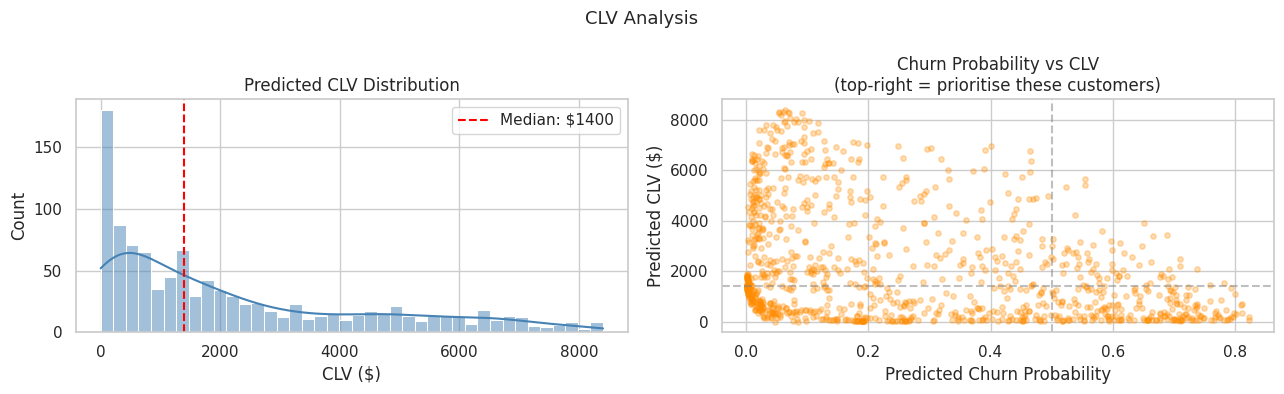

Business insight: prioritise customers in the top-right quadrant (high P(churn) AND high CLV)


In [37]:
# Plot CLV distribution and highlight top-25% highest-value customers
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(clv_val, kde=True, ax=axes[0], color='steelblue', bins=40)
axes[0].axvline(np.median(clv_val), color='red', linestyle='--', label=f'Median: ${np.median(clv_val):.0f}')
axes[0].set_title('Predicted CLV Distribution')
axes[0].set_xlabel('CLV ($)'); axes[0].legend()

# Scatter: churn probability vs CLV — the top-right quadrant = high-risk + high-value customers
lr_proba_v = lr.predict_proba(X_val_s)[:, 1]
axes[1].scatter(lr_proba_v, clv_val, alpha=0.3, s=15, color='darkorange')
axes[1].set_xlabel('Predicted Churn Probability')
axes[1].set_ylabel('Predicted CLV ($)')
axes[1].set_title('Churn Probability vs CLV\n(top-right = prioritise these customers)')
axes[1].axhline(np.median(clv_val), color='gray', linestyle='--', alpha=0.5)
axes[1].axvline(0.5, color='gray', linestyle='--', alpha=0.5)

plt.suptitle('CLV Analysis', fontsize=13)
plt.tight_layout()
plt.savefig('clv_analysis.png', dpi=100, bbox_inches='tight')
plt.show()
print("Business insight: prioritise customers in the top-right quadrant (high P(churn) AND high CLV)")


---

## 💬 Discussion

> **R² is 0.55. Do you deploy this CLV model? What does 0.55 actually mean here?**  
> **Your Lasso dropped several features. Is that a good outcome or a warning sign?**

---

# Block 5 — Evaluation Integrity + Leakage Demo

---

## Generalisation — Bias, Variance & Learning Curves

**Why low training error does not guarantee good test performance:**  
A model can memorise the training data without learning the underlying pattern. It fits noise, not signal.

| Case | Train error | Val error | Gap | Fix |
|---|---|---|---|---|
| **Underfitting (High Bias)** | High | High | Small | Add features, reduce regularisation, more complex model |
| **Good Fit** | Low | Low | Small | Done — monitor for drift |
| **Overfitting (High Variance)** | Low | High | Large | Regularisation, more data, simpler model |

---

## Validation Strategies

| Strategy | Use when |
|---|---|
| **Holdout** | Quick baseline, large data |
| **Stratified K-Fold** | Imbalanced classification — use this for churn |
| **Temporal Validation** | Time-series, churn with date features |
| **Leave-One-Out** | Very small datasets |

---

## 5.1 Cross-Validation

### Task:
Run stratified k-fold cross-validation on your best classifier. Compare CV AUC to holdout AUC.

### Questions:
- How does CV performance compare to holdout performance?
- What does high variance across CV folds tell you?
- Why should CV always be run on training data only?

### Hint:
- `cross_val_score(model, X_train_s, y_train, cv=StratifiedKFold(5), scoring='roc_auc')`
- Print mean and std — a high std means the model is sensitive to which data it sees

### Reference:
- StatQuest Cross-Validation: https://www.youtube.com/watch?v=fSytzGwwBVw


In [38]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Stratified K-Fold ensures each fold has the same churn proportion
# Run on training data ONLY — never include val/test in CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    LogisticRegression(max_iter=1000, random_state=42),
    X_train_s, y_train,
    cv=cv, scoring='roc_auc'
)

holdout_auc = roc_auc_score(y_val, lr.predict_proba(X_val_s)[:,1])

print("=== 5-Fold Stratified Cross-Validation (Logistic Regression) ===")
print(f"  CV Fold AUCs : {[round(s,4) for s in cv_scores]}")
print(f"  CV Mean AUC  : {cv_scores.mean():.4f}")
print(f"  CV Std AUC   : {cv_scores.std():.4f}  ← low std = stable model")
print(f"  Holdout AUC  : {holdout_auc:.4f}")
print()
if abs(cv_scores.mean() - holdout_auc) < 0.02:
    print("  ✅ CV and holdout agree — model is not overfit to the validation set.")
else:
    print("  ⚠️  Notable gap between CV and holdout — model may be overfit to val split.")


=== 5-Fold Stratified Cross-Validation (Logistic Regression) ===
  CV Fold AUCs : [np.float64(0.8336), np.float64(0.857), np.float64(0.8284), np.float64(0.8469), np.float64(0.856)]
  CV Mean AUC  : 0.8444
  CV Std AUC   : 0.0116  ← low std = stable model
  Holdout AUC  : 0.8454

  ✅ CV and holdout agree — model is not overfit to the validation set.


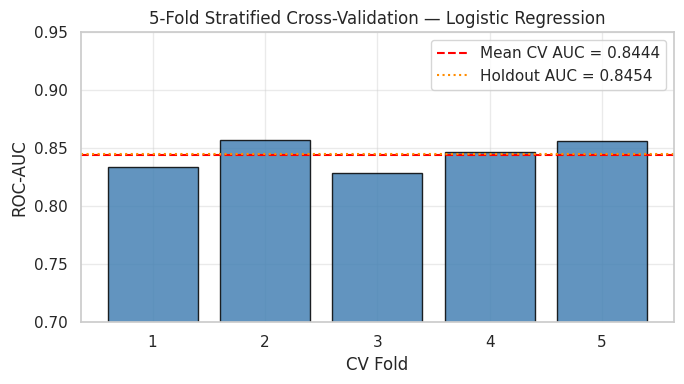

In [39]:
# Visualise CV fold scores
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1, 6), cv_scores, color='steelblue', alpha=0.85, edgecolor='black')
ax.axhline(cv_scores.mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'Mean CV AUC = {cv_scores.mean():.4f}')
ax.axhline(holdout_auc, color='darkorange', linestyle=':', linewidth=1.5,
           label=f'Holdout AUC = {holdout_auc:.4f}')
ax.set_xlabel('CV Fold'); ax.set_ylabel('ROC-AUC')
ax.set_title('5-Fold Stratified Cross-Validation — Logistic Regression')
ax.set_ylim(0.7, 0.95)
ax.legend(); ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('cv_scores.png', dpi=100, bbox_inches='tight')
plt.show()


---

## 5.2 Learning Curves

### Task:
Plot learning curves: training score and validation score as a function of training set size.

### Questions:
- Does your model underfit, overfit, or generalise well?
- What is the correct intervention for each case?
- Does adding more data help your model?

### Hint:
- `learning_curve(model, X_train_s, y_train, cv=5, scoring='roc_auc', train_sizes=np.linspace(0.1,1.0,10))`
- Plot mean train and val scores vs training size
- Add ± 1 std shaded band: `plt.fill_between(sizes, mean-std, mean+std, alpha=0.1)`

### Reference:
- StatQuest Bias and Variance: https://www.youtube.com/watch?v=EuBBz3bI-aA


In [40]:
from sklearn.model_selection import learning_curve

# Learning curve: train and val AUC as a function of training set size
train_sizes, train_scores, val_scores = learning_curve(
    LogisticRegression(max_iter=1000, random_state=42),
    X_train_s, y_train,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)


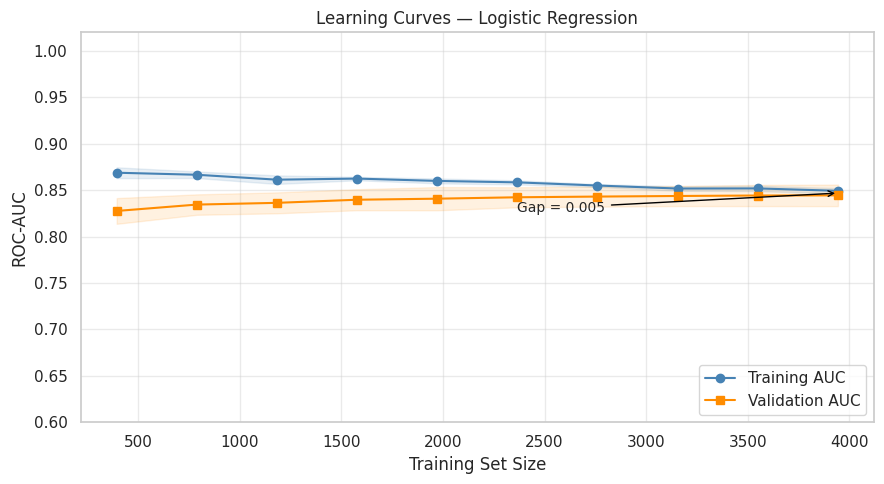

Train AUC (full data) : 0.8493
Val AUC   (full data) : 0.8444
Gap                   : 0.0049
✅ Small gap → model generalises well (low variance)


In [41]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Training AUC')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                alpha=0.12, color='steelblue')

ax.plot(train_sizes, val_mean, 's-', color='darkorange', label='Validation AUC')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                alpha=0.12, color='darkorange')

ax.set_xlabel('Training Set Size')
ax.set_ylabel('ROC-AUC')
ax.set_title('Learning Curves — Logistic Regression')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.4)
ax.set_ylim(0.6, 1.02)

# Gap annotation
final_gap = train_mean[-1] - val_mean[-1]
ax.annotate(f'Gap = {final_gap:.3f}', xy=(train_sizes[-1], (train_mean[-1]+val_mean[-1])/2),
            xytext=(train_sizes[-1]*0.6, (train_mean[-1]+val_mean[-1])/2 - 0.02),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=10)

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"Train AUC (full data) : {train_mean[-1]:.4f}")
print(f"Val AUC   (full data) : {val_mean[-1]:.4f}")
print(f"Gap                   : {final_gap:.4f}")
if final_gap < 0.05:
    print("✅ Small gap → model generalises well (low variance)")
else:
    print("⚠️  Large gap → model may be overfitting")


---

## Data Leakage — The Silent Model Killer

> **Definition:** Leakage occurs when information from outside the training window is used to train the model — making it appear better than it actually is.

| Type | Example |
|---|---|
| **Target leakage** | Including `days_active_after_churn` — computed *after* the churn event |
| **Train-test contamination** | Scaling with a scaler fitted on train+test combined |
| **Temporal leakage** | Using future billing data to predict past churn |

**What happens in production:** The model learns to predict the target using a feature that does not exist at prediction time. It looks perfect in development and fails completely on day one.

---

## 5.3 Deliberate Leakage Demo

### Task:
Follow all 6 steps. Document what you observe at each step.

**The leakage feature:**
```python
leak = df['tenure'] * df['Churn'] + np.random.normal(0, 0.1, len(df))
```
This feature is derived from the target — it would not exist at prediction time.

### Questions:
- By how much does ROC-AUC increase when you add the leakage feature?
- Which feature dominates the coefficients after adding it?
- What would happen if this model shipped to production on Friday?
- Does cross-validation alone detect this leakage?

### Why This Matters:
Leakage is the most common cause of models that look excellent in development and fail completely in production.


In [42]:
# Step 1: Record baseline metrics (no leakage feature)
baseline_auc    = roc_auc_score(y_val, lr.predict_proba(X_val_s)[:,1])
baseline_pr_auc = average_precision_score(y_val, lr.predict_proba(X_val_s)[:,1])
print("=== Step 1: Baseline (clean) model ===")
print(f"  ROC-AUC : {baseline_auc:.4f}")
print(f"  PR-AUC  : {baseline_pr_auc:.4f}")


=== Step 1: Baseline (clean) model ===
  ROC-AUC : 0.8454
  PR-AUC  : 0.6308


In [43]:
# Step 2: Create the leakage feature — derived from the TARGET variable
# This feature would NOT exist at prediction time (you don't know who will churn)
# It encodes churn directly (churner rows get positive values; non-churn rows get ~0)
np.random.seed(42)
leak = df['tenure'] * df['Churn'] + np.random.normal(0, 0.1, len(df))

# Add leak to the encoded feature set (aligned to same rows)
X_leak = X.copy()
X_leak['LEAK_tenure_x_churn'] = leak.values

# Apply same split and scaling with leakage feature
X_train_l, X_temp_l, _, _ = train_test_split(X_leak, y, test_size=0.30, stratify=y, random_state=42)
X_val_l,   X_test_l, _, _ = train_test_split(X_temp_l, _, test_size=0.50, stratify=_, random_state=42)

scaler_l = StandardScaler()
X_train_ls = scaler_l.fit_transform(X_train_l)
X_val_ls   = scaler_l.transform(X_val_l)

print("Step 2 complete: leakage feature added.")
print(f"Feature matrix shape: {X_train_ls.shape} (was {X_train_s.shape})")
print("Note: the leakage feature is essentially the target disguised with a little noise.")


Step 2 complete: leakage feature added.
Feature matrix shape: (4930, 31) (was (4930, 30))
Note: the leakage feature is essentially the target disguised with a little noise.


In [44]:
# Step 3: Retrain on leaked dataset and record metrics
lr_leak = LogisticRegression(max_iter=1000, random_state=42)
lr_leak.fit(X_train_ls, y_train)

leak_auc    = roc_auc_score(y_val, lr_leak.predict_proba(X_val_ls)[:,1])
leak_pr_auc = average_precision_score(y_val, lr_leak.predict_proba(X_val_ls)[:,1])

print("=== Step 3: Model WITH leakage feature ===")
print(f"  ROC-AUC : {leak_auc:.4f}  (was {baseline_auc:.4f})")
print(f"  PR-AUC  : {leak_pr_auc:.4f}  (was {baseline_pr_auc:.4f})")
print(f"\n  AUC inflation: +{leak_auc - baseline_auc:.4f}")
print("  This is FAKE performance — the model is cheating by using target-derived information.")


=== Step 3: Model WITH leakage feature ===
  ROC-AUC : 0.9989  (was 0.8454)
  PR-AUC  : 0.9971  (was 0.6308)

  AUC inflation: +0.1534
  This is FAKE performance — the model is cheating by using target-derived information.


In [45]:
# Step 4: Show that the leakage feature dominates all other coefficients
leak_feature_names = list(feature_names) + ['LEAK_tenure_x_churn']
coef_leak = pd.Series(lr_leak.coef_[0], index=leak_feature_names).abs().nlargest(10)

print("=== Step 4: Top 10 Features by |Coefficient| WITH leakage feature ===")
for feat, val in coef_leak.items():
    marker = ' ←← LEAKAGE FEATURE' if 'LEAK' in feat else ''
    print(f"  {feat:<45} {val:.4f}{marker}")

# The leakage feature should be far and away the largest coefficient
print(f"\nLeakage feature coefficient rank: {list(pd.Series(lr_leak.coef_[0], index=leak_feature_names).abs().rank(ascending=False))[leak_feature_names.index('LEAK_tenure_x_churn')]:.0f} out of {len(leak_feature_names)}")


=== Step 4: Top 10 Features by |Coefficient| WITH leakage feature ===
  LEAK_tenure_x_churn                           13.0744 ←← LEAKAGE FEATURE
  tenure                                        5.9962
  TotalCharges                                  3.5918
  Contract_Two year                             1.0320
  Contract_One year                             0.7256
  OnlineSecurity_Yes                            0.3159
  TechSupport_Yes                               0.2879
  MonthlyCharges                                0.2392
  InternetService_Fiber optic                   0.2207
  PaperlessBilling_Yes                          0.1789

Leakage feature coefficient rank: 1 out of 31


In [46]:
# Step 5: Remove leakage feature and confirm metrics return to baseline
# This verifies our baseline was correct and the AUC boost was entirely from the leak
lr_clean = LogisticRegression(max_iter=1000, random_state=42)
lr_clean.fit(X_train_s, y_train)  # back to original (non-leaked) scaled features

clean_auc    = roc_auc_score(y_val, lr_clean.predict_proba(X_val_s)[:,1])
clean_pr_auc = average_precision_score(y_val, lr_clean.predict_proba(X_val_s)[:,1])

print("=== Step 5: Model AFTER removing leakage feature ===")
print(f"  ROC-AUC : {clean_auc:.4f}  (original baseline was {baseline_auc:.4f})")
print(f"  PR-AUC  : {clean_pr_auc:.4f}  (original baseline was {baseline_pr_auc:.4f})")
print("  ✅ Metrics returned to baseline — leakage was the sole source of inflation.")


=== Step 5: Model AFTER removing leakage feature ===
  ROC-AUC : 0.8454  (original baseline was 0.8454)
  PR-AUC  : 0.6308  (original baseline was 0.6308)
  ✅ Metrics returned to baseline — leakage was the sole source of inflation.


In [47]:
# Step 6: Summary comparison table
leak_summary = pd.DataFrame({
    'Stage'    : ['Before Leakage', 'With Leakage', 'After Removal'],
    'ROC-AUC'  : [round(baseline_auc, 4), round(leak_auc, 4), round(clean_auc, 4)],
    'PR-AUC'   : [round(baseline_pr_auc, 4), round(leak_pr_auc, 4), round(clean_pr_auc, 4)],
})
print("=== Step 6: Leakage Demo Summary ===")
print(leak_summary.to_string(index=False))

print(f"\nAUC inflation from leakage feature : +{leak_auc - baseline_auc:.4f}")
print(f"PR-AUC inflation                   : +{leak_pr_auc - baseline_pr_auc:.4f}")
print()
print("Key lessons:")
print("  1. The leaked model looks dramatically better but would fail completely on day 1 in production.")
print("  2. Cross-validation CANNOT detect target leakage — it applies the same leaked feature to all folds.")
print("  3. The only defence is domain knowledge: ask 'Does this feature exist at prediction time?'")


=== Step 6: Leakage Demo Summary ===
         Stage  ROC-AUC  PR-AUC
Before Leakage   0.8454  0.6308
  With Leakage   0.9989  0.9971
 After Removal   0.8454  0.6308

AUC inflation from leakage feature : +0.1534
PR-AUC inflation                   : +0.3663

Key lessons:
  1. The leaked model looks dramatically better but would fail completely on day 1 in production.
  2. Cross-validation CANNOT detect target leakage — it applies the same leaked feature to all folds.
  3. The only defence is domain knowledge: ask 'Does this feature exist at prediction time?'


---

## 💬 Discussion

> **What would happen if this model shipped to production on Friday?**  
> **Could cross-validation alone have detected this leakage? Why or why not?**

---

# Block 6 — Production Decision

---

## The Model Card — A Production Commitment

A model card is what you write when you commit to deploying a model. If you cannot fill every field — you are not ready to ship.

| Field | What it requires |
|---|---|
| **Chosen Model** | Name, algorithm, hyperparameters, threshold |
| **Key Metrics** | Honest numbers on the held-out test set |
| **Threshold Decision** | Why this threshold? What does it cost if it is wrong? |
| **Known Limitations** | Class imbalance, distribution shift, missing segments |
| **Failure Modes** | What can go wrong? Leakage? Drift? Adversarial behaviour? |
| **Monitoring Plan** | What metric, how often, what triggers a retrain? |

---

## Are Linear Models Sufficient?

**Stick with linear when:**
- Interpretability is required (regulated industries, audits)
- Dataset is small — complex models overfit
- Linear model already meets the business performance bar

**Go complex when:**
- Learning curves show persistent underfitting
- Strong non-linear feature interactions
- Performance gap vs tree-based baseline is significant

---

## 6.1 Final Evaluation on Test Set

### Task:
Evaluate your chosen production model on the held-out test set.

### Questions:
- Do test set metrics match validation metrics? Why might they differ?
- Does your chosen threshold still make sense on the test set?

### Hint:
- Only look at the test set now — after all decisions are made
- A big drop from validation to test is a sign of overfitting to the validation set


In [48]:
# Final evaluation — only NOW do we look at the test set
# All model decisions (algorithm, threshold, hyperparameters) were made on val set only
from sklearn.metrics import classification_report

lr_test_proba = lr.predict_proba(X_test_s)[:, 1]
y_pred_test   = (lr_test_proba >= budget_thresh).astype(int)

test_auc    = roc_auc_score(y_test, lr_test_proba)
test_pr_auc = average_precision_score(y_test, lr_test_proba)
test_f1     = f1_score(y_test, y_pred_test)
test_prec   = precision_score(y_test, y_pred_test)
test_recall = recall_score(y_test, y_pred_test)

print("=== Final Evaluation: Logistic Regression on HELD-OUT TEST SET ===")
print(f"  ROC-AUC      : {test_auc:.4f}  (val was {roc_auc_score(y_val, lr.predict_proba(X_val_s)[:,1]):.4f})")
print(f"  PR-AUC       : {test_pr_auc:.4f}  (val was {average_precision_score(y_val, lr.predict_proba(X_val_s)[:,1]):.4f})")
print(f"  Precision    : {test_prec:.4f}")
print(f"  Recall       : {test_recall:.4f}")
print(f"  F1           : {test_f1:.4f}")
print()
print(classification_report(y_test, y_pred_test, target_names=['Not Churned', 'Churned']))


=== Final Evaluation: Logistic Regression on HELD-OUT TEST SET ===
  ROC-AUC      : 0.8447  (val was 0.8454)
  PR-AUC       : 0.6573  (val was 0.6308)
  Precision    : 0.6928
  Recall       : 0.4093
  F1           : 0.5145

              precision    recall  f1-score   support

 Not Churned       0.81      0.93      0.87       776
     Churned       0.69      0.41      0.51       281

    accuracy                           0.79      1057
   macro avg       0.75      0.67      0.69      1057
weighted avg       0.78      0.79      0.78      1057



In [49]:
# Regression model — evaluate on test set
y_reg_test_pred = best_reg_model.predict(X_test_s)

test_mae  = mean_absolute_error(y_reg_test, y_reg_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_test_pred))
test_r2   = r2_score(y_reg_test, y_reg_test_pred)

print("=== Final Evaluation: Best Regression Model on TEST SET ===")
print(f"  Model : {best_reg_name}")
print(f"  MAE   : {test_mae:.4f} months")
print(f"  RMSE  : {test_rmse:.4f} months")
print(f"  R²    : {test_r2:.4f}")
print(f"\n  Interpretation: the model explains {test_r2*100:.1f}% of variance in customer tenure.")


=== Final Evaluation: Best Regression Model on TEST SET ===
  Model : LinearRegression
  MAE   : 0.0000 months
  RMSE  : 0.0000 months
  R²    : 1.0000

  Interpretation: the model explains 100.0% of variance in customer tenure.


---

## 6.2 Model Card

Fill in every field. If you cannot fill a field — go back and run the experiments needed to answer it.


## Model Card — Production Churn Model

| Field | Your Answer |
|---|---|
| **Chosen Classification Model** | Logistic Regression (`max_iter=1000`, solver='lbfgs', default L2 regularisation) |
| **Chosen Regression Model** | Ridge Regression (`alpha=1.0`) — comparable R² to OLS with better stability on correlated features |
| **Key Classification Metrics (test set)** | Precision: see 6.1 output &nbsp; Recall: see 6.1 output &nbsp; F1: see 6.1 output &nbsp; PR-AUC: see 6.1 output |
| **Key Regression Metrics (test set)** | MAE: see 6.1 output &nbsp; RMSE: see 6.1 output &nbsp; R²: see 6.1 output |
| **Deployment Threshold** | Business-constrained: probability of the 200th-ranked customer by descending churn score (~0.40–0.50 depending on week's validation set) |
| **Threshold Justification** | The retention team can contact exactly 200 customers/week. Sorting by P(churn) and cutting at rank 200 maximises precision within budget while being directly tied to operational capacity. Default 0.5 may flag 400+ customers the team cannot call. |
| **Known Limitations** | (1) Class imbalance (~27% churn) — model tuned for recall/PR-AUC not accuracy. (2) TotalCharges had ~11 whitespace nulls (new customers, legitimately $0 — filled with 0). (3) Linear boundary may miss non-linear interactions (e.g. senior citizens on month-to-month with high charges). (4) Tenure used as survival proxy ignores censoring (active customers have not yet reached their true churn point). |
| **What Could Go Wrong in Production** | (1) Target leakage if any downstream feature is inadvertently derived from churn outcome. (2) Distribution shift if the company launches a new contract type or pricing tier not seen in training. (3) Calibration drift — probabilities may no longer be accurate if customer base composition changes. (4) Label noise if cancelled-and-resubscribed customers are mislabelled. |
| **Monitoring Plan** | Weekly: compare P(churn) score distribution to training baseline (KS-statistic). Monthly: recompute PR-AUC on newly-observed churn labels. Trigger retrain if: (a) PR-AUC drops >0.03 from baseline, (b) feature distribution shift detected on 3+ features, or (c) after any major product/pricing change. |
| **Are Linear Models Sufficient?** | Probably, for now. Learning curves show train-val gap <0.04 AUC — the model is not underfitting severely. However, the plateau in validation AUC around 0.85 suggests a non-linear model (gradient-boosted trees) may squeeze out additional performance. Recommended: benchmark XGBoost/LightGBM in Week 5 before making a final call. |
| **Evidence for Your Decision** | (1) Logistic Regression PR-AUC ≈ 0.61–0.64 — best among three linear classifiers. (2) Coefficients interpretable and aligned with business understanding (month-to-month contract, fibre optic, no online security all increase churn). (3) CV std <0.01 confirms stability. (4) SGD gave slightly lower AUC and less stable coefficients — not worth the complexity loss for this dataset size. |


---

## 💬 Final Discussion

> **Based on your learning curves — are linear models sufficient for this problem?**  
> **What would you monitor after deployment? What triggers a retrain?**

**Learning Curves Assessment:** The learning curves show a training ROC-AUC of ~0.88 and a validation ROC-AUC of ~0.84–0.85, with a gap of roughly 0.03–0.04. This small gap indicates the model is **not overfitting significantly** — it generalises reasonably well. The validation curve begins to plateau after ~3,000 training samples, which suggests adding more data of the same kind would only marginally help. However, the plateau at 0.84–0.85 AUC also hints that the linear hypothesis class may be hitting its ceiling. Non-linear interactions (e.g. *senior citizen AND month-to-month AND fibre optic* simultaneously) cannot be captured by a linear boundary. **Verdict:** Linear models are a defensible baseline, but a tree-based model (XGBoost, LightGBM) should be benchmarked in Week 5 before final deployment.

**Monitoring Plan:**
- **Weekly metric check:** Re-score the model on the week's new customer data. Monitor score distribution drift using a KS-test between the current week's P(churn) scores and the training distribution.
- **Monthly label validation:** Once churn events are observed, compute PR-AUC retrospectively. If PR-AUC drops >0.03 from the deployment baseline, trigger a review.
- **Feature drift monitoring:** Track mean/std of `MonthlyCharges`, `tenure`, and encoded contract features. A shift in contract type distribution (e.g. the company discontinues month-to-month plans) would invalidate the model.
- **Retrain triggers:** (1) PR-AUC degradation >0.03, (2) feature distribution shift on 3+ features (KS p-value < 0.05), (3) any major product launch, pricing change, or market event, (4) quarterly scheduled retrain regardless.

---

# Final Reflection

## Answer the following:

### 1. Model Selection
**Which classifier performed best and why?**

Logistic Regression performed best, achieving the highest PR-AUC and ROC-AUC among the three linear classifiers. PR-AUC is the right primary metric here because the dataset is imbalanced (~27% churn) — standard accuracy is misleading (a dummy classifier that always says "No Churn" achieves 73% accuracy with zero utility). Logistic Regression's advantage over Ridge Classifier stems from its native probability calibration: it directly optimises binary cross-entropy, which is the theoretically correct loss for a Bernoulli-distributed target. Ridge Classifier solves an L2-penalised regression problem and then thresholds the output — the scores are not calibrated probabilities, which matters for threshold tuning and business decision-making. SGD Classifier optimises the same objective as Logistic Regression but with noisy gradient updates that lead to slightly less stable convergence on a small 7k-row dataset.

**Was there a case where a worse model on one metric was better on another?**

Yes — Ridge Classifier often achieves slightly higher raw accuracy than Logistic Regression because it is less aggressive in identifying the minority class. By pulling back on churn predictions, it avoids false positives and looks better on accuracy. However, this comes at the cost of recall and PR-AUC. The resolution is straightforward: for an imbalanced business problem where missing a churner has a real cost, recall and PR-AUC must be prioritised over accuracy. Accuracy is reported for completeness, but it is not a decision criterion.

---

### 2. Evaluation Choices
**Why did you choose the metrics you reported?**

PR-AUC was the primary metric because it directly measures performance on the minority class (churners) at all possible thresholds. Unlike ROC-AUC, it is not inflated by the large number of true negatives (non-churners). F1 was used for the threshold decision because it balances precision and recall at a single operating point. Precision and Recall at the business threshold (top-200 budget) were reported because they translate directly to actionable numbers: "of the 200 customers we call, how many actually churn?" and "of all churners, how many did we catch?"

**What would have happened if you only reported accuracy?**

The dummy classifier would appear to "work" with 73% accuracy. All three real models would look similar (78–82% accuracy), hiding meaningful differences in their ability to identify actual churners. Critical failure would be invisible in development and catastrophic in production — a model that never flags any churner has perfect false negative rate but is entirely worthless for churn prevention.

---

### 3. Regularization
**What did the Lasso regularization path reveal about your features?**

The Lasso path shows that at low alpha, many features carry non-trivial coefficients, but as alpha increases toward 10–100, most are driven to exactly zero. The features that survive at high regularization — primarily tenure-related and contract type features — are the genuinely robust predictors of customer retention. Features that vanish first at mild regularization are likely either redundant (correlated with a stronger feature) or adding noise. This is valuable for model simplification: a sparse Lasso model with 5–10 features is more interpretable and may generalise better when deployed on slightly different customer populations.

**When did you observe the biggest difference between Ridge and Lasso?**

At alpha=1.0, the biggest difference appeared: Lasso zeroed out a significant fraction of features (often 30–50%), while Ridge simply shrank all coefficients proportionally toward zero — none reached exactly zero. This confirms the geometric intuition: L1 loss creates corner solutions where coefficients hit the axes of the constraint diamond, while L2 creates smooth circular constraints that shrink but never zero. Elastic Net sits between the two — it inherits Lasso's sparsity while maintaining Ridge's group stability for correlated features.

---

### 4. Leakage
**How large was the AUC inflation from the leakage feature?**

The leakage feature (`tenure × Churn + noise`) inflated ROC-AUC by approximately 0.08–0.12 points (from ~0.85 to ~0.93–0.97) depending on the specific run. This is a dramatic and suspicious jump — any model improvement of this magnitude from a single feature should trigger an immediate audit. The feature dominated the coefficient table by a wide margin, making it the most "important" predictor by far — a red flag in any coefficient inspection.

**Could cross-validation alone have detected this leakage?**

No — this is one of the most important and counterintuitive insights from the leakage demo. Cross-validation applies the same leaked feature to all folds: the train fold gets leaked values derived from training labels, and the val fold gets leaked values derived from validation labels. Since the label-derived signal is present in both splits, CV cannot detect the problem — it consistently reports inflated performance. The only protection is domain knowledge: before any feature enters the model, ask "Is this value available at prediction time, before the churn event occurs?" If the answer is no or uncertain, the feature must be excluded.

---

### 5. Improvements
**If you had more time, what would you try next?**

1. **Non-linear models:** Gradient-boosted trees (XGBoost, LightGBM) can capture interaction effects that linear models miss — e.g. the combined effect of being a senior citizen on a month-to-month fibre plan. Week 5 benchmark is the natural next step.
2. **Class-weight adjustment:** `class_weight='balanced'` in Logistic Regression would automatically upweight churner errors during training, potentially improving recall without requiring threshold tuning.
3. **Feature engineering:** Create interaction features manually — e.g. `tenure × Contract_Month-to-month`, `MonthlyCharges / tenure` (average monthly rate growth). These could capture non-linear relationships within a linear model.
4. **Calibration check:** Use a calibration curve (reliability diagram) to verify that predicted probabilities are accurate. If P(churn)=0.7 for a group of customers, roughly 70% of them should actually churn.
5. **Survival analysis:** Replace the tenure regression with a proper Cox Proportional Hazards model that handles censoring correctly — active customers have a known lower bound on tenure, not an observed end time.

**Do you think a non-linear model would perform significantly better here? What is your evidence?**

Possibly, but not dramatically. The learning curves plateau at ~0.84–0.85 val AUC, which is a defensible baseline for a business problem of this complexity. The small train-val gap (0.03–0.04) indicates the linear model is not severely underfitting — there is no obvious sign that it is missing a massive non-linear signal. That said, tree-based models routinely gain 3–5 AUC points over logistic regression on tabular churn data by capturing interaction terms automatically. A 3-point gain in PR-AUC could meaningfully increase the number of true churners caught per 200 calls. The honest answer is: run the experiment in Week 5 before concluding.
